## Task 0

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [69]:
DATA_DIR = Path(".")

COMMODITY_FILE = DATA_DIR / "Commodities Data thru 15May25.xlsx"

commodity_xls = pd.ExcelFile(COMMODITY_FILE)

print("Commodity file sheets:")
print(commodity_xls.sheet_names)

Commodity file sheets:
['Return Indices', 'Assets']


In [3]:
raw_indices = pd.read_excel(
    COMMODITY_FILE,
    sheet_name="Return Indices",
    na_values=["#N/A N/A", "#N/A", "N/A", "NA", ""]
)

In [4]:
return_indices = raw_indices.copy()

date_col = return_indices.columns[0]
return_indices = return_indices.rename(columns={date_col: "Date"})
return_indices["Date"] = pd.to_datetime(return_indices["Date"], errors="coerce")
return_indices = return_indices.dropna(subset=["Date"])
return_indices = return_indices.set_index("Date")
return_indices = return_indices.sort_index()
return_indices = return_indices.apply(pd.to_numeric, errors="coerce")

return_indices.head()

,LIVE CATTLE FUTR Aug25,LEAN HOGS FUTURE Jul25,COFFEE 'C' FUTURE Jul25,CORN FUTURE Jul25,COTTON NO.2 FUTR Jul25,SOYBEAN FUTURE Jul25,SUGAR #11 (WORLD) Jul25,WHEAT FUTURE(CBT) Jul25,BRENT CRUDE FUTR Jul25,COPPER FUTURE Jul25,GASOLINE RBOB FUT Jun25,GOLD 100 OZ FUTR Jun25,NATURAL GAS FUTR Jun25,SILVER FUTURE Jul25,PLATINUM FUTURE Jul25,WTI CRUDE FUTURE Jun25,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA FUTURE Jul25,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,100.000000,NaN,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN
1969-01-02,99.195767,NaN,NaN,99.579019,100.760109,99.863919,100.977591,99.816382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.305113,NaN
1969-01-03,98.746032,NaN,NaN,100.004551,101.269383,99.611198,101.298991,99.631766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.430847,NaN
1969-01-06,98.746032,NaN,NaN,100.216179,101.847066,99.416796,100.325864,98.804487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.209556,NaN
1969-01-07,99.195767,NaN,NaN,100.216179,100.874126,99.183515,99.352736,97.882405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.826488,NaN


In [5]:
# check time range and number of assets
print("Start date:", return_indices.index.min())
print("End date:", return_indices.index.max())
print("Number of assets:", return_indices.shape[1])                                                                                                     

Start date: 1969-01-01 00:00:00
End date: 2025-05-15 00:00:00
Number of assets: 23


In [6]:
# assets info
assets = pd.read_excel(
    COMMODITY_FILE,
    sheet_name="Assets"
)

assets.head()

,Commodity,Sector
0,LIVE CATTLE,Agri & livestock
1,LEAN HOGS,Agri & livestock
2,COFFEE 'C',Agri & livestock
3,CORN,Agri & livestock
4,COTTON NO.2,Agri & livestock


In [7]:
# clean up asset info
assets = assets.copy()

assets["Commodity"] = assets["Commodity"].astype(str).str.strip()
assets["Sector"] = assets["Sector"].astype(str).str.strip()

assets = assets.dropna(subset=["Commodity", "Sector"])

assets

,Commodity,Sector
0,LIVE CATTLE,Agri & livestock
1,LEAN HOGS,Agri & livestock
2,COFFEE 'C',Agri & livestock
3,CORN,Agri & livestock
4,COTTON NO.2,Agri & livestock
5,SOYBEAN,Agri & livestock
6,SUGAR #11,Agri & livestock
7,WHEAT FUTURE,Agri & livestock
8,BRENT CRUDE,Energy
9,COPPER FUTURE,Metals


In [8]:
assets["Sector"].value_counts()

Sector
Agri & livestock    9
Metals              9
Energy              5
Name: count, dtype: int64

In [9]:
# the assets name in the return indices sheet are not indentical to the assets name in the assets sheet, so we need to match them up.
def normalise_name(x):
    return " ".join(str(x).upper().split())


old_cols = return_indices.columns.tolist()
asset_names = assets["Commodity"].tolist()

rename_dict = {}
unmatched_assets = []

for asset in asset_names:
    asset_norm = normalise_name(asset)
    
    matches = [
        col for col in old_cols
        if asset_norm in normalise_name(col)
    ]
    
    if len(matches) == 1:
        rename_dict[matches[0]] = asset
    else:
        unmatched_assets.append((asset, matches))

print("Matched columns:", len(rename_dict))
print("Unmatched assets:")
print(unmatched_assets)

Matched columns: 23
Unmatched assets:
[]


In [10]:
return_indices = return_indices.rename(columns=rename_dict)

return_indices = return_indices[asset_names]

return_indices.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,100.000000,NaN,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN
1969-01-02,99.195767,NaN,NaN,99.579019,100.760109,99.863919,100.977591,99.816382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.305113,NaN
1969-01-03,98.746032,NaN,NaN,100.004551,101.269383,99.611198,101.298991,99.631766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.430847,NaN
1969-01-06,98.746032,NaN,NaN,100.216179,101.847066,99.416796,100.325864,98.804487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.209556,NaN
1969-01-07,99.195767,NaN,NaN,100.216179,100.874126,99.183515,99.352736,97.882405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.826488,NaN


In [11]:
print(return_indices.columns.tolist())
print(return_indices.shape)

['LIVE CATTLE', 'LEAN HOGS', "COFFEE 'C'", 'CORN', 'COTTON NO.2', 'SOYBEAN', 'SUGAR #11', 'WHEAT FUTURE', 'BRENT CRUDE', 'COPPER FUTURE', 'GASOLINE RBOB', 'GOLD 100 OZ', 'NATURAL GAS', 'SILVER', 'PLATINUM', 'WTI CRUDE', 'LME NICKEL', 'LME COPPER', 'LME ALUMINIUM', 'LME LEAD', 'LME ZINC', 'COCOA', 'HEATING OIL']
(14707, 23)


In [12]:
# the original data is return indices, we have to transform it to returns by calculating the percentage change
commodity_returns = return_indices.pct_change()

commodity_returns.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1969-01-02,-0.008042,NaN,NaN,-0.004210,0.007601,-0.001361,0.009776,-0.001836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023051,NaN
1969-01-03,-0.004534,NaN,NaN,0.004273,0.005054,-0.002531,0.003183,-0.001850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001229,NaN
1969-01-06,0.000000,NaN,NaN,0.002116,0.005704,-0.001952,-0.009606,-0.008303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021686,NaN
1969-01-07,0.004554,NaN,NaN,0.000000,-0.009553,-0.002346,-0.009700,-0.009332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013802,NaN


In [13]:
commodity_returns = commodity_returns.dropna(how="all")

print("Start date:", commodity_returns.index.min())
print("End date:", commodity_returns.index.max())
print("Shape:", commodity_returns.shape)

Start date: 1969-01-02 00:00:00
End date: 2025-05-15 00:00:00
Shape: (14706, 23)


In [14]:
# calculate the commodity market factor as the simple average return according to the task requirement
commodity_market_factor = commodity_returns.mean(axis=1, skipna=True)
commodity_market_factor.name = "Commodity_Market_Factor"

commodity_market_factor.head()

Date
1969-01-02    0.003568
1969-01-03    0.000689
1969-01-06   -0.004818
1969-01-07   -0.005740
1969-01-08   -0.003637
Name: Commodity_Market_Factor, dtype: float64

In [15]:
returns_with_factor = commodity_returns.copy()
returns_with_factor["Commodity_Market_Factor"] = commodity_market_factor

returns_with_factor.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL,Commodity_Market_Factor
Date,,,,,,,,,,,,,,,,,,,,,,,,
1969-01-02,-0.008042,NaN,NaN,-0.004210,0.007601,-0.001361,0.009776,-0.001836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023051,NaN,0.003568
1969-01-03,-0.004534,NaN,NaN,0.004273,0.005054,-0.002531,0.003183,-0.001850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001229,NaN,0.000689
1969-01-06,0.000000,NaN,NaN,0.002116,0.005704,-0.001952,-0.009606,-0.008303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021686,NaN,-0.004818
1969-01-07,0.004554,NaN,NaN,0.000000,-0.009553,-0.002346,-0.009700,-0.009332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013802,NaN,-0.005740
1969-01-08,0.008108,NaN,NaN,0.002112,-0.002562,0.001960,-0.022869,0.009420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021628,NaN,-0.003637


In [16]:
# split the data into train and test sets based on the provided date ranges
TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"

commodity_returns_train = commodity_returns.loc[:TRAIN_END]
commodity_returns_test = commodity_returns.loc[TEST_START:]

market_factor_train = commodity_market_factor.loc[:TRAIN_END]
market_factor_test = commodity_market_factor.loc[TEST_START:]

print("Commodity returns train:", commodity_returns_train.index.min(), "to", commodity_returns_train.index.max(), commodity_returns_train.shape)
print("Commodity returns test:", commodity_returns_test.index.min(), "to", commodity_returns_test.index.max(), commodity_returns_test.shape)

print("Market factor train:", market_factor_train.index.min(), "to", market_factor_train.index.max(), market_factor_train.shape)
print("Market factor test:", market_factor_test.index.min(), "to", market_factor_test.index.max(), market_factor_test.shape)

Commodity returns train: 1969-01-02 00:00:00 to 2019-12-31 00:00:00 (13304, 23)
Commodity returns test: 2020-01-01 00:00:00 to 2025-05-15 00:00:00 (1402, 23)
Market factor train: 1969-01-02 00:00:00 to 2019-12-31 00:00:00 (13304,)
Market factor test: 2020-01-01 00:00:00 to 2025-05-15 00:00:00 (1402,)


In [17]:
def summary_statistics(returns, annualisation=252):
    
    summary = pd.DataFrame(index=returns.columns)
    
    summary["Observations"] = returns.count()
    summary["Mean Daily Return"] = returns.mean()
    summary["Daily Volatility"] = returns.std()
    summary["Annualised Return"] = returns.mean() * annualisation
    summary["Annualised Volatility"] = returns.std() * np.sqrt(annualisation)
    summary["Sharpe Ratio"] = summary["Annualised Return"] / summary["Annualised Volatility"]
    summary["Skewness"] = returns.skew()
    summary["Kurtosis"] = returns.kurtosis()
    summary["Min Daily Return"] = returns.min()
    summary["Max Daily Return"] = returns.max()
    
    return summary


eda_summary_full = summary_statistics(commodity_returns)
eda_summary_train = summary_statistics(commodity_returns_train)
eda_summary_test = summary_statistics(commodity_returns_test)

eda_summary_full

,Observations,Mean Daily Return,Daily Volatility,Annualised Return,Annualised Volatility,Sharpe Ratio,Skewness,Kurtosis,Min Daily Return,Max Daily Return
LIVE CATTLE,14706,0.000213,0.009978,0.053592,0.158399,0.338338,-0.052751,1.420960,-0.061598,0.056041
LEAN HOGS,10206,-0.000087,0.015747,-0.021812,0.249981,-0.087253,0.009606,1.570208,-0.085198,0.077763
COFFEE 'C',13756,0.000223,0.021688,0.056293,0.344292,0.163504,0.570496,9.257769,-0.188235,0.261511
CORN,14706,-0.000021,0.014346,-0.005242,0.227737,-0.023019,0.124990,3.077612,-0.089950,0.090416
COTTON NO.2,14706,0.000062,0.014794,0.015564,0.234854,0.066273,0.002624,2.237306,-0.101913,0.086392
SOYBEAN,14706,0.000181,0.014197,0.045655,0.225375,0.202572,-0.068074,3.270708,-0.139828,0.133458
SUGAR #11,14706,0.000091,0.022931,0.022830,0.364013,0.062718,-0.022122,3.373199,-0.181102,0.153328
WHEAT FUTURE,14706,-0.000033,0.016472,-0.008287,0.261487,-0.031692,0.226290,2.406680,-0.095284,0.094766
BRENT CRUDE,9624,0.000564,0.021875,0.142227,0.347259,0.409570,-0.426290,12.965309,-0.320620,0.209645
COPPER FUTURE,9506,0.000261,0.015854,0.065869,0.251668,0.261728,-0.041857,4.032092,-0.110475,0.123456


In [18]:
commodity_corr = commodity_returns.corr()

commodity_corr.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
LIVE CATTLE,1.000000,0.303241,0.039580,0.098339,0.064216,0.112845,0.042321,0.083738,0.086167,0.093546,0.120685,0.042892,0.047416,0.071627,0.069679,0.063860,0.055443,0.082101,0.067264,0.040376,0.065189,0.044341,0.067787
LEAN HOGS,0.303241,1.000000,0.026507,0.080942,0.062097,0.090529,0.053710,0.078833,0.060063,0.067915,0.046184,0.016412,0.023310,0.051407,0.040118,0.006308,0.047770,0.063377,0.062382,0.056687,0.060977,0.028173,0.050966
COFFEE 'C',0.039580,0.026507,1.000000,0.099684,0.077552,0.111617,0.115621,0.094509,0.089918,0.130796,0.140619,0.084412,0.038943,0.121430,0.128949,0.058614,0.087102,0.114447,0.096221,0.087966,0.115054,0.138137,0.072165
CORN,0.098339,0.080942,0.099684,1.000000,0.208300,0.640587,0.142577,0.622665,0.163223,0.162594,0.208699,0.131297,0.086959,0.173948,0.134022,0.104318,0.103595,0.138783,0.121571,0.097294,0.131759,0.077924,0.148619
COTTON NO.2,0.064216,0.062097,0.077552,0.208300,1.000000,0.230336,0.122664,0.187477,0.166559,0.192658,0.232297,0.092560,0.049553,0.133660,0.127359,0.079059,0.118780,0.171715,0.135958,0.116154,0.148828,0.078926,0.129960


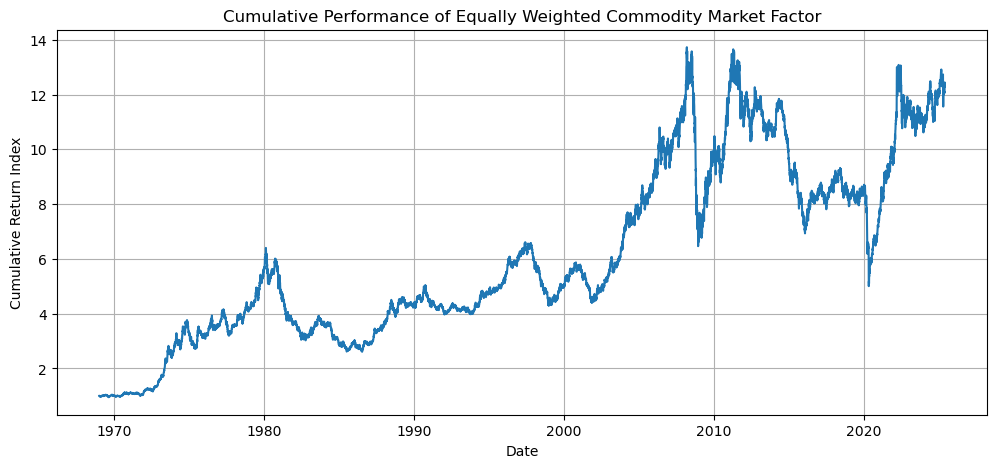

In [19]:
market_cum_return = (1 + commodity_market_factor.dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(market_cum_return)
plt.title("Cumulative Performance of Equally Weighted Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.grid(True)
plt.show()

In [20]:
sector_map = assets.set_index("Commodity")["Sector"]

missing_sector = [col for col in commodity_returns.columns if col not in sector_map.index]
print("Assets missing sector mapping:", missing_sector)

Assets missing sector mapping: []


In [21]:
sector_returns = (
    commodity_returns
    .T
    .groupby(sector_map)
    .mean()
    .T
)

sector_returns.head()

Sector,Agri & livestock,Energy,Metals
Date,,,
1969-01-02,0.003568,NaN,NaN
1969-01-03,0.000689,NaN,NaN
1969-01-06,-0.004818,NaN,NaN
1969-01-07,-0.005740,NaN,NaN
1969-01-08,-0.003637,NaN,NaN


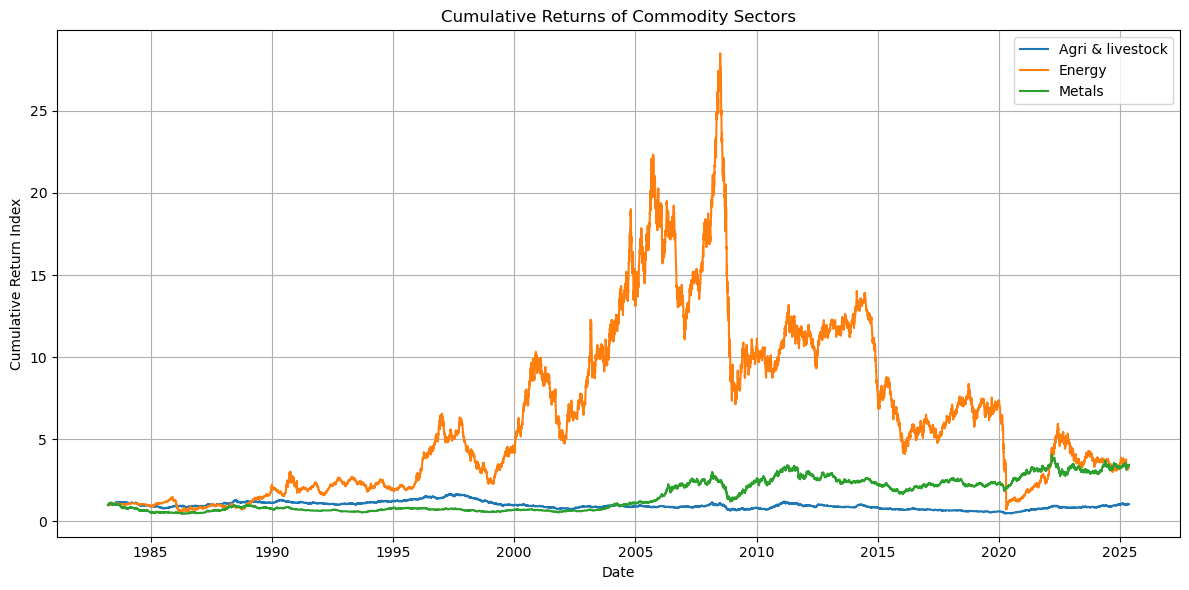

In [22]:
sector_returns_common = sector_returns.dropna(how="any")
sector_cum_returns_common = (1 + sector_returns_common).cumprod()

plt.figure(figsize=(12, 6))

for col in sector_cum_returns_common.columns:
    plt.plot(sector_cum_returns_common.index, sector_cum_returns_common[col], label=col)

plt.title("Cumulative Returns of Commodity Sectors")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 1

In [23]:
# -----------------------------
# Task 1: Strict Adaptive TSMOM parameters
# -----------------------------

LOOKBACK_CANDIDATES = [63, 126, 252]   # 3-month, 6-month, 12-month trend horizons
VOL_LOOKBACK_DAYS = 60                 # realised volatility for risk scaling
REBALANCE_FREQ = "M"                   # monthly rebalance
ANNUALISATION = 252

TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"

In [24]:
# set rebalance at the end of the month
def get_rebalance_mask(index, frequency="M"):

    if frequency.upper() == "D":
        return pd.Series(True, index=index)

    periods = pd.Series(index.to_period(frequency), index=index)
    rebalance_mask = periods.ne(periods.shift(-1))
    
    return rebalance_mask.fillna(True)

In [25]:
rebalance_mask = get_rebalance_mask(commodity_returns.index, REBALANCE_FREQ)

print("Number of rebalance dates:", rebalance_mask.sum())
print(commodity_returns.index[rebalance_mask][:10])

Number of rebalance dates: 677
DatetimeIndex(['1969-01-31', '1969-02-28', '1969-03-31', '1969-04-30', '1969-05-30', '1969-06-30', '1969-07-31', '1969-08-29', '1969-09-30', '1969-10-31'], dtype='datetime64[ns]', name='Date', freq=None)


In [27]:
def compute_past_cumulative_returns(returns, lookback_candidates):
    """
    Compute past cumulative returns for each candidate horizon.
    
    Output:
    dictionary:
        key = lookback horizon
        value = DataFrame of past cumulative returns
    """
    
    past_returns = {}
    
    for lb in lookback_candidates:
        past_cum_return = (
            (1 + returns)
            .rolling(window=lb, min_periods=lb)
            .apply(np.prod, raw=True)
            - 1
        )
        
        past_returns[lb] = past_cum_return
    
    return past_returns

In [28]:
# calculate the benchmark as the past cumulative return / realised volatility to select the best trend horizon
def compute_trend_scores(returns, lookback_candidates, annualisation=252):
    
    past_returns = compute_past_cumulative_returns(
        returns=returns,
        lookback_candidates=lookback_candidates
    )
    
    trend_scores = {}
    realised_vols_by_horizon = {}
    
    for lb in lookback_candidates:
        realised_vol = (
            returns
            .rolling(window=lb, min_periods=lb)
            .std()
            * np.sqrt(annualisation)
        )
        
        score = past_returns[lb] / realised_vol.replace(0, np.nan)
        
        trend_scores[lb] = score
        realised_vols_by_horizon[lb] = realised_vol
    
    return trend_scores, past_returns, realised_vols_by_horizon

In [29]:
# select lookback horizon for each assets at each rebalance date
def generate_strict_adaptive_tsmom_signals(
    returns,
    lookback_candidates=[63, 126, 252],
    rebalance_freq="M",
    annualisation=252
):

    
    trend_scores, past_returns, realised_vols_by_horizon = compute_trend_scores(
        returns=returns,
        lookback_candidates=lookback_candidates,
        annualisation=annualisation
    )
    
    adaptive_signal = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    selected_lookback = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    selected_score = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    
    for asset in returns.columns:
        asset_scores = pd.DataFrame({
            lb: trend_scores[lb][asset]
            for lb in lookback_candidates
        })
        
        asset_past_returns = pd.DataFrame({
            lb: past_returns[lb][asset]
            for lb in lookback_candidates
        })
        
        best_lb = asset_scores.abs().idxmax(axis=1)
        
        valid_rows = asset_scores.notna().any(axis=1)
        
        for date in returns.index[valid_rows]:
            lb = best_lb.loc[date]
            
            selected_lookback.loc[date, asset] = lb
            selected_score.loc[date, asset] = asset_scores.loc[date, lb]
            
            selected_return = asset_past_returns.loc[date, lb]
            
            if selected_return > 0:
                adaptive_signal.loc[date, asset] = 1.0
            elif selected_return < 0:
                adaptive_signal.loc[date, asset] = -1.0
            else:
                adaptive_signal.loc[date, asset] = 0.0
    
    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        
        adaptive_signal.loc[~rebalance_mask, :] = np.nan
        selected_lookback.loc[~rebalance_mask, :] = np.nan
        selected_score.loc[~rebalance_mask, :] = np.nan
        
        adaptive_signal = adaptive_signal.ffill()
        selected_lookback = selected_lookback.ffill()
        selected_score = selected_score.ffill()
    
    return adaptive_signal, selected_lookback, selected_score, trend_scores, past_returns

In [30]:
adaptive_signals, selected_lookback, selected_score, adaptive_trend_scores, adaptive_past_returns = generate_strict_adaptive_tsmom_signals(
    returns=commodity_returns,
    lookback_candidates=LOOKBACK_CANDIDATES,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

C:\Users\26434\AppData\Local\Temp\ipykernel_25864\876990489.py:31: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_25864\876990489.py:31: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_25864\876990489.py:31: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_25864\876990489.py:31: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a futu

In [31]:
adaptive_signal_distribution = adaptive_signals.stack().value_counts(dropna=True).sort_index()
adaptive_signal_distribution

-1.0    130327
 0.0        21
 1.0    135605
Name: count, dtype: int64

In [32]:
selected_lookback_distribution = selected_lookback.stack().value_counts(dropna=True).sort_index()
selected_lookback_distribution


63.0      40601
126.0     66837
252.0    158515
Name: count, dtype: int64

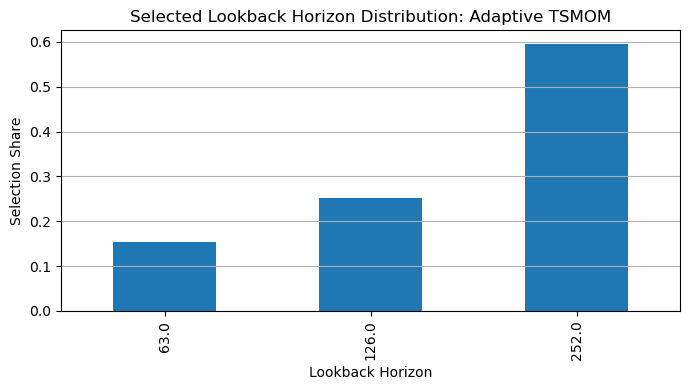

In [33]:
selected_lookback_share = selected_lookback.stack().value_counts(normalize=True, dropna=True).sort_index()
plt.figure(figsize=(7, 4))
selected_lookback_share.sort_index().plot(kind="bar")
plt.title("Selected Lookback Horizon Distribution: Adaptive TSMOM")
plt.xlabel("Lookback Horizon")
plt.ylabel("Selection Share")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Each lookback candidates has been selected which means the adaptive TSMOM strategy is effective

In [34]:
# alternative strategy: TSMOM signal based on fixed 12 months lookback 
def generate_tsmom_signals(returns, lookback=252, rebalance_freq="M"):

    
    past_cum_return = (
        (1 + returns)
        .rolling(window=lookback, min_periods=lookback)
        .apply(np.prod, raw=True)
        - 1
    )
    
    raw_signal = pd.DataFrame(
        np.where(past_cum_return > 0, 1,
                 np.where(past_cum_return < 0, -1, 0)),
        index=returns.index,
        columns=returns.columns
    )
    
    raw_signal = raw_signal.where(past_cum_return.notna())
    
    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        signal = raw_signal.copy()
        signal.loc[~rebalance_mask, :] = np.nan
        signal = signal.ffill()
    else:
        signal = raw_signal.copy()
    
    return signal, past_cum_return

In [35]:
baseline_signals, baseline_past_returns = generate_tsmom_signals(
    returns=commodity_returns,
    rebalance_freq=REBALANCE_FREQ
)

baseline_signals.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-12,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-13,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-14,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-15,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0


In [36]:
signal_distribution = baseline_signals.stack().value_counts(dropna=True).sort_index()
signal_distribution

-1.0    134231
 1.0    127360
Name: count, dtype: int64

In [37]:
# construct inverse volatility weighted portfolio weights based on the input signals and the realised volatility estimate
def construct_inverse_vol_weights(
    returns,
    signals,
    vol_lookback=60,
    rebalance_freq="M",
    annualisation=252
):

    
    # realized volatility estimate
    realised_vol = (
        returns
        .rolling(window=vol_lookback, min_periods=vol_lookback)
        .std()
        * np.sqrt(annualisation)
    )
    
    # inverse volatility
    inv_vol = 1 / realised_vol.replace(0, np.nan)
    
    # raw weights
    raw_weights_daily = signals * inv_vol
    

    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        raw_weights = raw_weights_daily.copy()
        raw_weights.loc[~rebalance_mask, :] = np.nan
        raw_weights = raw_weights.ffill()
    else:
        raw_weights = raw_weights_daily.copy()
    
    # gross exposure normalisation
    raw_weights = raw_weights.replace([np.inf, -np.inf], np.nan)
    raw_weights = raw_weights.where(returns.notna(), np.nan)

    gross_exposure = raw_weights.abs().sum(axis=1).replace(0, np.nan)
    weights = raw_weights.div(gross_exposure, axis=0).fillna(0.0)
    
    return weights, realised_vol

In [38]:
baseline_weights, baseline_realised_vol = construct_inverse_vol_weights(
    returns=commodity_returns,
    signals=baseline_signals,
    vol_lookback=VOL_LOOKBACK_DAYS,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

baseline_weights.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-12,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-13,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-14,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-15,0.069836,0.045952,0.031084,-0.057554,-0.045894,-0.065558,0.042495,-0.053297,-0.032921,-0.030854,-0.036719,0.043671,-0.017110,-0.032718,-0.043026,-0.029803,-0.043256,-0.046502,-0.062644,-0.062956,-0.053109,0.016622,-0.036418


In [39]:
gross_exposure = baseline_weights.abs().sum(axis=1)
net_exposure = baseline_weights.sum(axis=1)

print(gross_exposure.describe())
print(net_exposure.describe())

count    14706.000000
mean         0.982388
std          0.131540
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64
count    14706.000000
mean        -0.024527
std          0.462655
min         -1.000000
25%         -0.350376
50%         -0.005084
75%          0.307159
max          1.000000
dtype: float64


In [40]:
adaptive_weights, adaptive_realised_vol = construct_inverse_vol_weights(
    returns=commodity_returns,
    signals=adaptive_signals,
    vol_lookback=VOL_LOOKBACK_DAYS,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

adaptive_weights.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-12,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-13,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-14,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-15,0.069836,0.045952,0.031084,-0.057554,-0.045894,-0.065558,-0.042495,-0.053297,-0.032921,0.030854,-0.036719,0.043671,0.017110,-0.032718,-0.043026,-0.029803,-0.043256,-0.046502,-0.062644,-0.062956,-0.053109,0.016622,-0.036418


In [41]:
adaptive_gross_exposure = adaptive_weights.abs().sum(axis=1)
adaptive_net_exposure = adaptive_weights.sum(axis=1)

print(adaptive_gross_exposure.describe())
print(adaptive_net_exposure.describe())

count    14706.000000
mean         0.995784
std          0.064796
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64
count    14706.000000
mean         0.011943
std          0.465773
min         -1.000000
25%         -0.320428
50%          0.021500
75%          0.390164
max          1.000000
dtype: float64


In [42]:
# to avoid look-ahead bias, we shift the weights by 1 day
def backtest_from_weights(returns, weights, strategy_name="Strategy"):
    
    shifted_weights = weights.shift(1)
    
    asset_contributions = shifted_weights * returns
    
    strategy_returns = asset_contributions.sum(axis=1, min_count=1)
    
    active_mask = shifted_weights.abs().sum(axis=1) > 0
    strategy_returns = strategy_returns.loc[active_mask].fillna(0.0)
    asset_contributions = asset_contributions.loc[strategy_returns.index].fillna(0.0)
    
    strategy_returns.name = strategy_name
    
    return strategy_returns, asset_contributions

In [43]:
baseline_strategy_returns, baseline_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=baseline_weights,
    strategy_name="Baseline_TSMOM"
)

baseline_strategy_returns.head()

Date
1970-01-01    0.000000
1970-01-02    0.000000
1970-01-05   -0.004691
1970-01-06    0.004881
1970-01-07    0.004009
Name: Baseline_TSMOM, dtype: float64

In [44]:
print("Strategy start date:", baseline_strategy_returns.index.min())
print("Strategy end date:", baseline_strategy_returns.index.max())
print("Number of observations:", baseline_strategy_returns.shape[0])

Strategy start date: 1970-01-01 00:00:00
Strategy end date: 2025-05-15 00:00:00
Number of observations: 14446


In [45]:
adaptive_strategy_returns, adaptive_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=adaptive_weights,
    strategy_name="Adaptive_TSMOM"
)

adaptive_strategy_returns.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: Adaptive_TSMOM, dtype: float64

In [46]:
print("Adaptive TSMOM start date:", adaptive_strategy_returns.index.min())
print("Adaptive TSMOM end date:", adaptive_strategy_returns.index.max())
print("Number of observations:", adaptive_strategy_returns.shape[0])

Adaptive TSMOM start date: 1969-04-01 00:00:00
Adaptive TSMOM end date: 2025-05-15 00:00:00
Number of observations: 14643


In [47]:
def calculate_max_drawdown(return_series):

    return_series = return_series.dropna()
    cumulative = (1 + return_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()


def performance_summary(returns, annualisation=252):
    
    if isinstance(returns, pd.Series):
        returns = returns.to_frame()
    
    summary = pd.DataFrame(index=returns.columns)
    
    n_obs = returns.count()
    total_return = (1 + returns).prod() - 1
    years = n_obs / annualisation
    
    cagr = (1 + total_return) ** (1 / years) - 1
    
    ann_mean = returns.mean() * annualisation
    ann_vol = returns.std() * np.sqrt(annualisation)
    sharpe = ann_mean / ann_vol
    
    downside_vol = returns.where(returns < 0).std() * np.sqrt(annualisation)
    sortino = ann_mean / downside_vol
    
    max_dd = returns.apply(calculate_max_drawdown)
    calmar = cagr / max_dd.abs()
    
    hit_rate = (returns > 0).sum() / n_obs
    
    summary["Observations"] = n_obs
    summary["Total Return"] = total_return
    summary["CAGR"] = cagr
    summary["Annualised Mean Return"] = ann_mean
    summary["Annualised Volatility"] = ann_vol
    summary["Sharpe Ratio"] = sharpe
    summary["Sortino Ratio"] = sortino
    summary["Max Drawdown"] = max_dd
    summary["Calmar Ratio"] = calmar
    summary["Skewness"] = returns.skew()
    summary["Kurtosis"] = returns.kurtosis()
    summary["Hit Rate"] = hit_rate
    
    return summary

In [48]:
comparison_returns = pd.concat(
    [
        baseline_strategy_returns,
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

comparison_returns.head()

,Baseline_TSMOM,Commodity_Market_Factor
Date,,
1970-01-01,0.000000,0.000000
1970-01-02,0.000000,0.000000
1970-01-05,-0.004691,0.003388
1970-01-06,0.004881,0.000453
1970-01-07,0.004009,0.002583


In [49]:
summary_full = performance_summary(comparison_returns, annualisation=ANNUALISATION)
summary_train = performance_summary(comparison_returns.loc[:TRAIN_END], annualisation=ANNUALISATION)
summary_test = performance_summary(comparison_returns.loc[TEST_START:], annualisation=ANNUALISATION)

print("Full sample performance:")
display(summary_full.round(4))

print("Training sample performance:")
display(summary_train.round(4))

print("Test sample performance:")
display(summary_test.round(4))

Full sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,14446,46.7893,0.0698,0.0716,0.0907,0.7894,1.0749,-0.3736,0.1868,-0.2411,5.4409,0.5209
Commodity_Market_Factor,14446,11.4774,0.0450,0.0531,0.1342,0.3954,0.5297,-0.6354,0.0708,-0.5904,9.2871,0.5130


Training sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,13044,36.6852,0.0726,0.0742,0.0902,0.8226,1.1130,-0.3736,0.1944,-0.2983,5.2353,0.5222
Commodity_Market_Factor,13044,7.7450,0.0428,0.0504,0.1302,0.3869,0.5431,-0.5924,0.0722,-0.1468,3.7970,0.5083


Test sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,1402,0.2681,0.0436,0.0472,0.0949,0.4972,0.7156,-0.1570,0.2779,0.2218,6.9933,0.5093
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


In [50]:
comparison_returns = pd.concat(
    [
        adaptive_strategy_returns,
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

comparison_returns.head()

,Adaptive_TSMOM,Commodity_Market_Factor
Date,,
1969-04-01,-0.000383,0.009329
1969-04-02,0.001361,0.000504
1969-04-03,-0.001822,-0.001189
1969-04-04,0.000000,0.000000
1969-04-07,0.000048,0.003684


In [51]:
summary_full = performance_summary(comparison_returns, annualisation=ANNUALISATION)
summary_train = performance_summary(comparison_returns.loc[:TRAIN_END], annualisation=ANNUALISATION)
summary_test = performance_summary(comparison_returns.loc[TEST_START:], annualisation=ANNUALISATION)

print("Full sample performance:")
display(summary_full.round(4))

print("Training sample performance:")
display(summary_train.round(4))

print("Test sample performance:")
display(summary_test.round(4))

Full sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,14643,76.8705,0.0778,0.0790,0.0895,0.8825,1.2185,-0.3173,0.2453,-0.0991,5.7391,0.5197
Commodity_Market_Factor,14643,11.5249,0.0445,0.0525,0.1336,0.3927,0.5256,-0.6354,0.0700,-0.5910,9.3540,0.5127


Training sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,13241,53.1796,0.0789,0.0799,0.0884,0.9036,1.2431,-0.3036,0.2600,-0.1674,5.4329,0.5205
Commodity_Market_Factor,13241,7.7783,0.0422,0.0497,0.1296,0.3839,0.5384,-0.5924,0.0713,-0.1473,3.8375,0.5080


Test sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


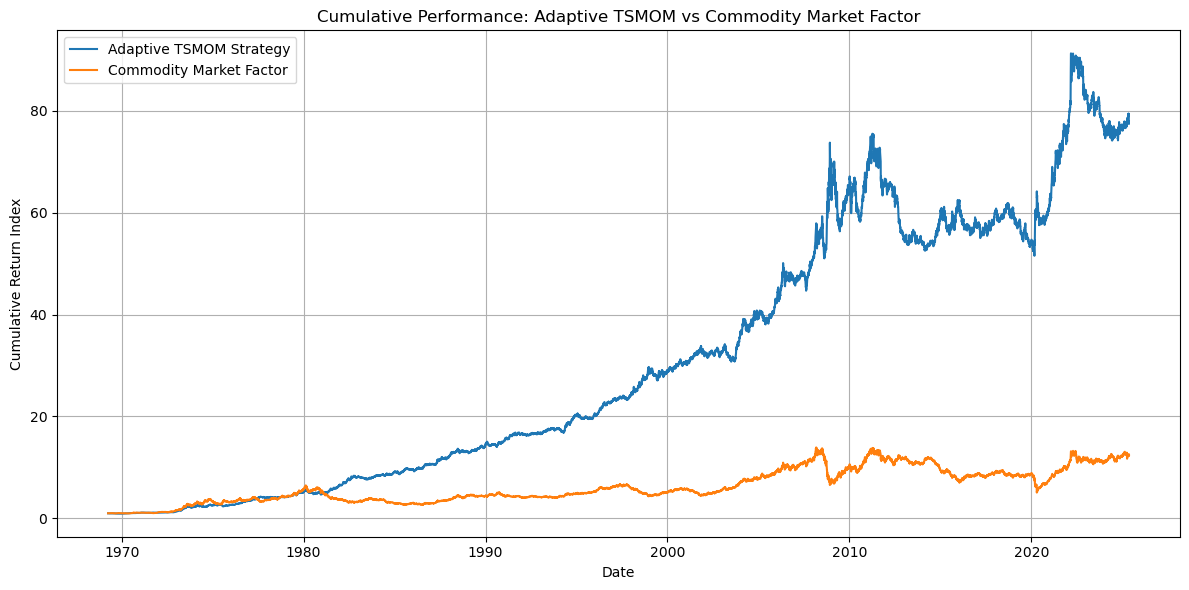

In [52]:
cumulative_comparison = (1 + comparison_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_comparison["Adaptive_TSMOM"], label="Adaptive TSMOM Strategy")
plt.plot(cumulative_comparison["Commodity_Market_Factor"], label="Commodity Market Factor")
plt.title("Cumulative Performance: Adaptive TSMOM vs Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

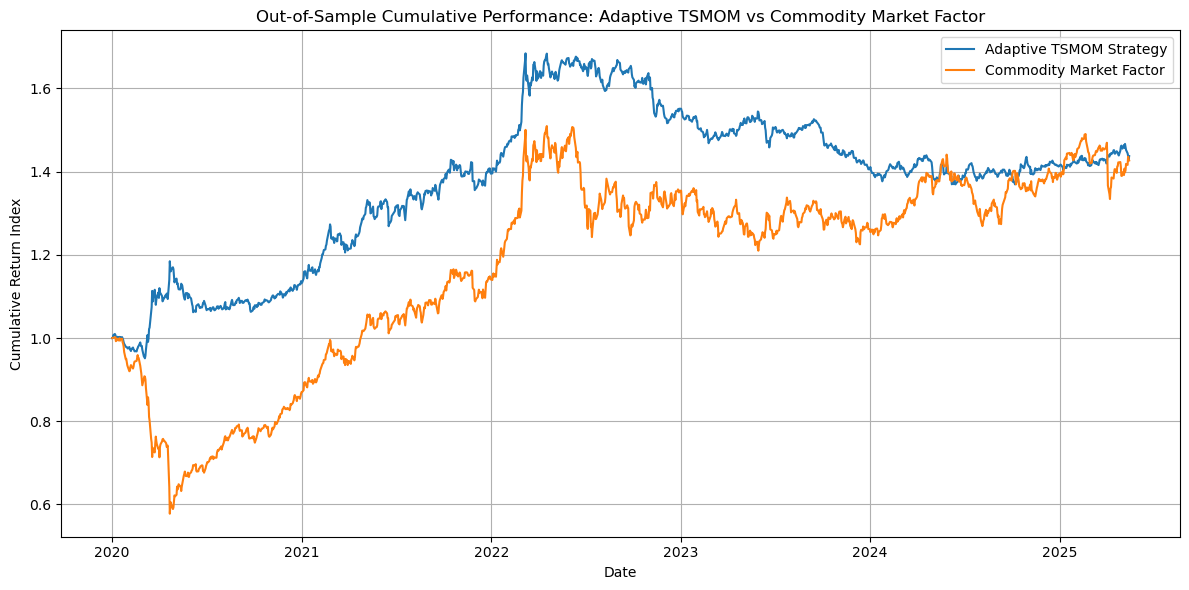

In [53]:
comparison_returns_test = comparison_returns.loc[TEST_START:]
cumulative_comparison_test = (1 + comparison_returns_test).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_comparison_test["Adaptive_TSMOM"], label="Adaptive TSMOM Strategy")
plt.plot(cumulative_comparison_test["Commodity_Market_Factor"], label="Commodity Market Factor")
plt.title("Out-of-Sample Cumulative Performance: Adaptive TSMOM vs Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
strategy_comparison = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM"),
        baseline_strategy_returns.rename("Fixed_12M_TSMOM"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

strategy_comparison_summary_test = performance_summary(
    strategy_comparison.loc[TEST_START:], 
    annualisation=ANNUALISATION
)

strategy_comparison_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Fixed_12M_TSMOM,1402,0.2681,0.0436,0.0472,0.0949,0.4972,0.7156,-0.1570,0.2779,0.2218,6.9933,0.5093
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


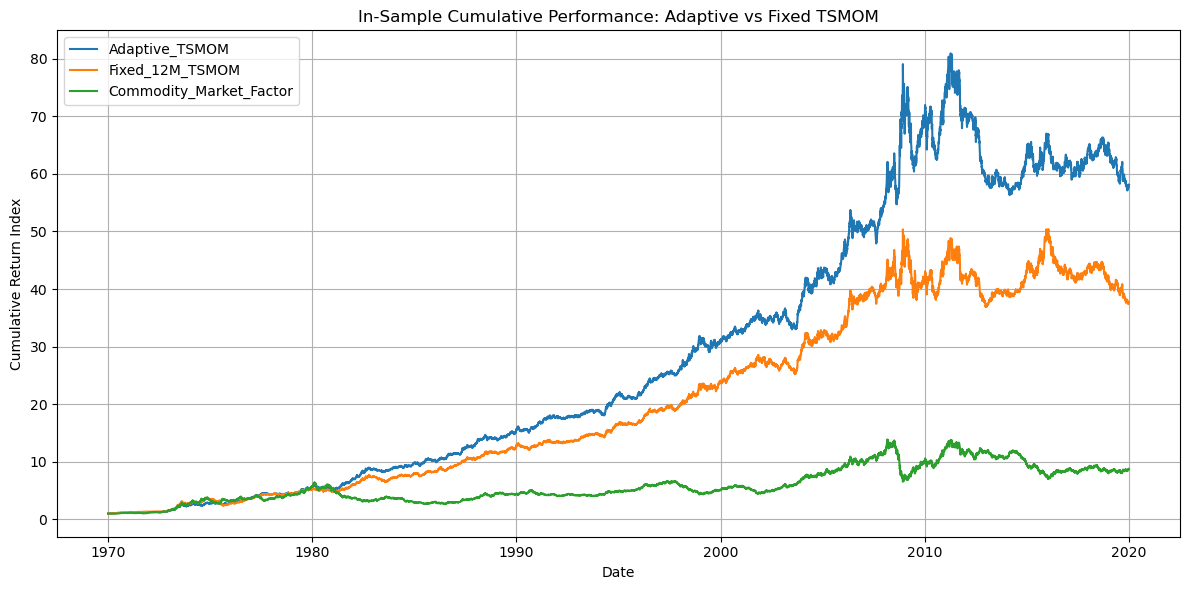

In [55]:
strategy_comparison_train_cum = (1 + strategy_comparison.loc[:TEST_START]).cumprod()

plt.figure(figsize=(12, 6))
for col in strategy_comparison_train_cum.columns:
    plt.plot(strategy_comparison_train_cum[col], label=col)

plt.title("In-Sample Cumulative Performance: Adaptive vs Fixed TSMOM")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

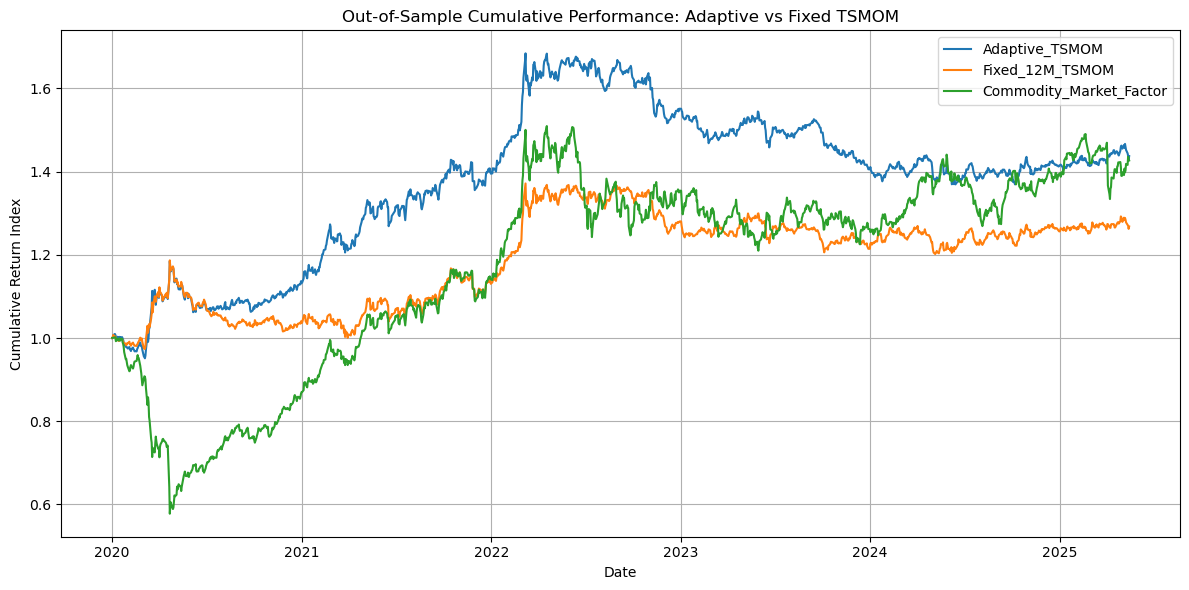

In [56]:
strategy_comparison_test_cum = (1 + strategy_comparison.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))
for col in strategy_comparison_test_cum.columns:
    plt.plot(strategy_comparison_test_cum[col], label=col)

plt.title("Out-of-Sample Cumulative Performance: Adaptive vs Fixed TSMOM")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# run regression of strategy returns on the commodity market factor
def run_market_beta_regression(strategy_returns, market_factor, hac_lags=5):
    """
    Regress strategy returns on the commodity market factor.

    Model:
        strategy return = alpha + beta * commodity market factor + error

    HAC standard errors are used to account for heteroskedasticity 
    and mild autocorrelation.
    """

    reg_data = pd.concat(
        [
            strategy_returns.rename("Strategy_Return"),
            market_factor.rename("Commodity_Market_Factor")
        ],
        axis=1
    ).dropna()

    y = reg_data["Strategy_Return"]
    X = sm.add_constant(reg_data["Commodity_Market_Factor"])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )

    return model, reg_data

In [58]:
adaptive_market_beta_model_full, adaptive_reg_data_full = run_market_beta_regression(
    strategy_returns=adaptive_strategy_returns,
    market_factor=commodity_market_factor,
    hac_lags=5
)

print(adaptive_market_beta_model_full.summary())

                            OLS Regression Results                            
Dep. Variable:        Strategy_Return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.934
Date:                Sun, 24 May 2026   Prob (F-statistic):             0.0868
Time:                        15:09:12   Log-Likelihood:                 55078.
No. Observations:               14643   AIC:                        -1.102e+05
Df Residuals:                   14641   BIC:                        -1.101e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [59]:
adaptive_market_beta_model_test, adaptive_reg_data_test = run_market_beta_regression(
    strategy_returns=adaptive_strategy_returns.loc[TEST_START:],
    market_factor=commodity_market_factor.loc[TEST_START:],
    hac_lags=5
)

print(adaptive_market_beta_model_test.summary())

                            OLS Regression Results                            
Dep. Variable:        Strategy_Return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                   0.07766
Date:                Sun, 24 May 2026   Prob (F-statistic):              0.781
Time:                        15:09:14   Log-Likelihood:                 5131.9
No. Observations:                1402   AIC:                        -1.026e+04
Df Residuals:                    1400   BIC:                        -1.025e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

The R-squared is only 0.2%, indicating that the strategy is not primarily driven by passive exposure to the commodity market. There is no statistically significant evidence that the strategy is driven by commodity market beta in the test period. The estimated alpha is positive but not statistically significant in the test sample.

In [60]:
def compute_sector_contributions(asset_contributions, assets):

    sector_map = assets.set_index("Commodity")["Sector"]

    common_assets = [
        col for col in asset_contributions.columns
        if col in sector_map.index
    ]

    asset_contributions = asset_contributions[common_assets]

    sector_contributions = (
        asset_contributions
        .T
        .groupby(sector_map.loc[common_assets])
        .sum()
        .T
    )

    return sector_contributions

In [61]:
adaptive_sector_contributions = compute_sector_contributions(
    asset_contributions=adaptive_asset_contributions,
    assets=assets
)

adaptive_sector_contributions.head()

Sector,Agri & livestock,Energy,Metals
Date,,,
1969-04-01,-0.000383,0.0,0.0
1969-04-02,0.001361,0.0,0.0
1969-04-03,-0.001822,0.0,0.0
1969-04-04,0.000000,0.0,0.0
1969-04-07,0.000048,0.0,0.0


In [62]:
adaptive_sector_total_contribution = adaptive_sector_contributions.sum()
adaptive_total_strategy_arithmetic_return = adaptive_strategy_returns.sum()

adaptive_sector_contribution_table = pd.DataFrame({
    "Total Arithmetic Contribution": adaptive_sector_total_contribution,
    "Share of Total Arithmetic Return": adaptive_sector_total_contribution / adaptive_total_strategy_arithmetic_return,
    "Absolute Contribution Share": adaptive_sector_total_contribution.abs() / adaptive_sector_total_contribution.abs().sum()
})

adaptive_sector_contribution_table.round(4)

,Total Arithmetic Contribution,Share of Total Arithmetic Return,Absolute Contribution Share
Sector,,,
Agri & livestock,2.5473,0.5552,0.5552
Energy,0.9360,0.2040,0.2040
Metals,1.1050,0.2408,0.2408


In [63]:
adaptive_sector_contribution_train = adaptive_sector_contributions.loc[:TRAIN_END].sum()
adaptive_sector_contribution_test = adaptive_sector_contributions.loc[TEST_START:].sum()

adaptive_sector_contribution_train_test = pd.DataFrame({
    "Train Contribution": adaptive_sector_contribution_train,
    "Test Contribution": adaptive_sector_contribution_test
})

adaptive_sector_contribution_train_test["Train Share"] = (
    adaptive_sector_contribution_train_test["Train Contribution"]
    / adaptive_sector_contribution_train_test["Train Contribution"].sum()
)

adaptive_sector_contribution_train_test["Test Share"] = (
    adaptive_sector_contribution_train_test["Test Contribution"]
    / adaptive_sector_contribution_train_test["Test Contribution"].sum()
)

adaptive_sector_contribution_train_test.round(4)

,Train Contribution,Test Contribution,Train Share,Test Share
Sector,,,,
Agri & livestock,2.4074,0.1399,0.5734,0.3589
Energy,0.6884,0.2476,0.1640,0.6350
Metals,1.1026,0.0024,0.2626,0.0061


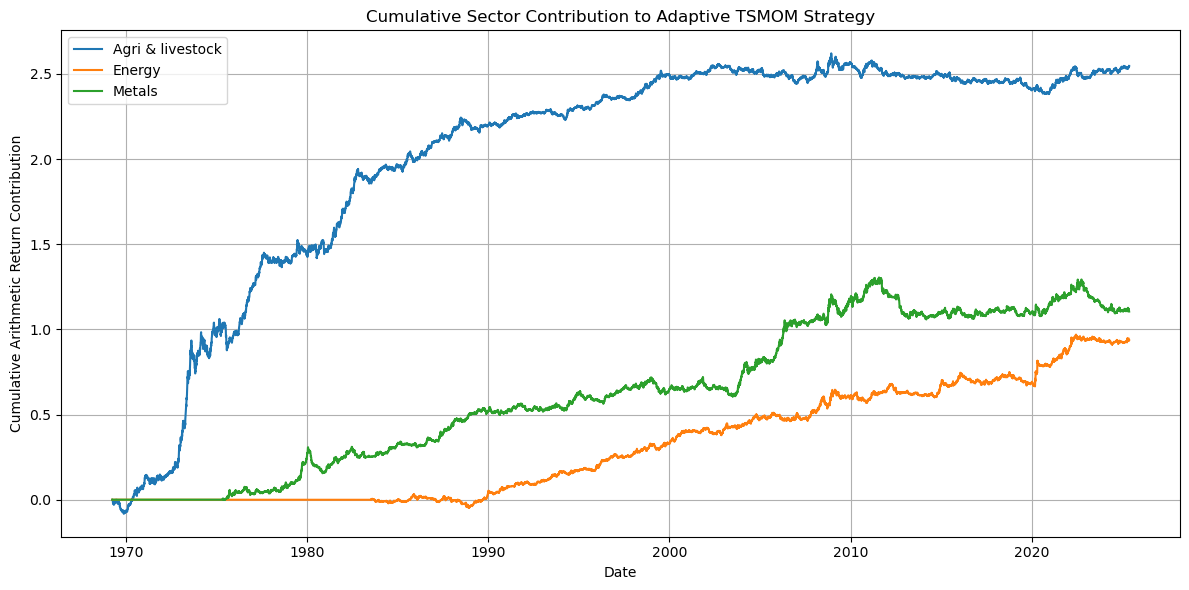

In [64]:
adaptive_sector_cumulative_contribution = adaptive_sector_contributions.cumsum()

plt.figure(figsize=(12, 6))

for sector in adaptive_sector_cumulative_contribution.columns:
    plt.plot(adaptive_sector_cumulative_contribution[sector], label=sector)

plt.title("Cumulative Sector Contribution to Adaptive TSMOM Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Arithmetic Return Contribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

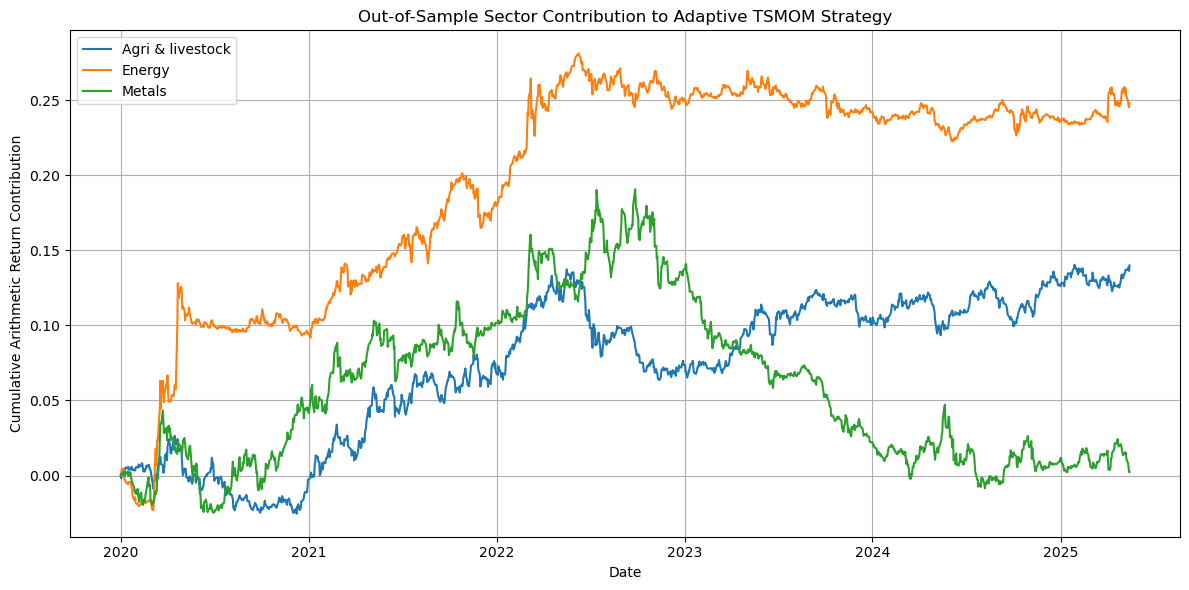

In [65]:
adaptive_sector_cumulative_contribution_test = adaptive_sector_contributions.loc[TEST_START:].cumsum()

plt.figure(figsize=(12, 6))

for sector in adaptive_sector_cumulative_contribution_test.columns:
    plt.plot(adaptive_sector_cumulative_contribution_test[sector], label=sector)

plt.title("Out-of-Sample Sector Contribution to Adaptive TSMOM Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Arithmetic Return Contribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [67]:
adaptive_gross_exposure = adaptive_weights.abs().sum(axis=1)
adaptive_net_exposure = adaptive_weights.sum(axis=1)

adaptive_exposure_summary = pd.DataFrame({
    "Gross Exposure": adaptive_gross_exposure,
    "Net Exposure": adaptive_net_exposure
})

adaptive_exposure_summary.describe().round(4)

,Gross Exposure,Net Exposure
count,14706.0000,14706.0000
mean,0.9958,0.0119
std,0.0648,0.4658
min,0.0000,-1.0000
25%,1.0000,-0.3204
50%,1.0000,0.0215
75%,1.0000,0.3902
max,1.0000,1.0000


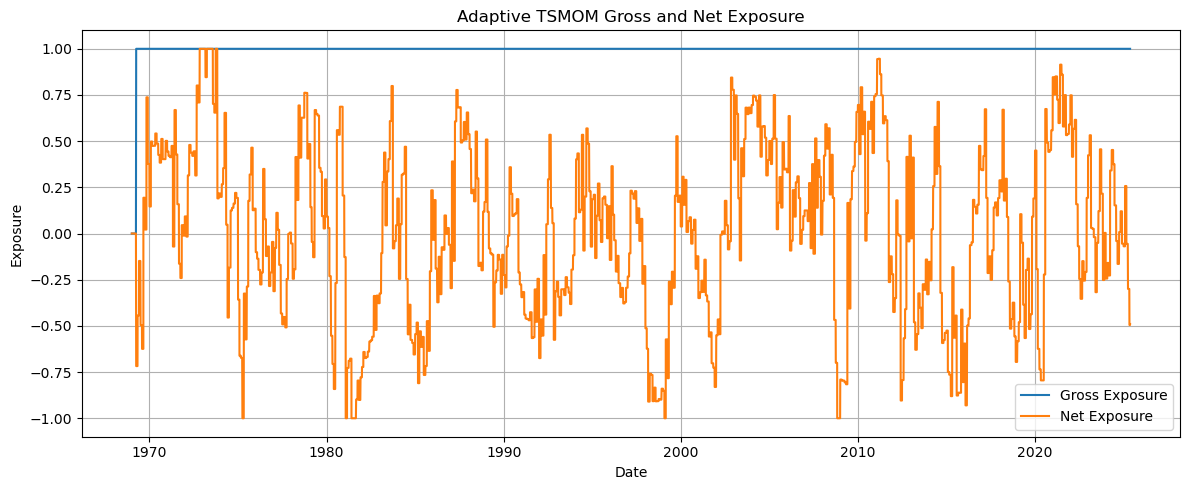

In [68]:
plt.figure(figsize=(12, 5))
plt.plot(adaptive_gross_exposure, label="Gross Exposure")
plt.plot(adaptive_net_exposure, label="Net Exposure")
plt.title("Adaptive TSMOM Gross and Net Exposure")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We control the gross exposure to 1 as we normalise the weights

# Task 2

In [71]:
DATA_DIR = Path(".")

AUXILIARY_FILE = DATA_DIR / "DataTables Updated thru 15May25.xlsx"

aux_xls = pd.ExcelFile(AUXILIARY_FILE)

print(aux_xls.sheet_names)

['VARIABLES', 'FX SPOT', 'ATM VOLS', '3M 25D RR', '3M DEPOSIT RATES', '10Y YIELD', 'EQUITY INDICES', 'COMDTY', 'CREDIT SPREADS', 'JPM EASI', 'IMM POSITIONING', '1M EUR FWD', 'BBG Formula']


In [74]:
def read_auxiliary_sheet(file_path, sheet_name):
    """
    Read and clean one auxiliary data sheet.
    
    The first column is assumed to be the date column.
    The remaining columns are converted to numeric values.
    """
    
    df = pd.read_excel(
        file_path,
        sheet_name=sheet_name,
        na_values=["#N/A N/A", "#N/A", "N/A", "NA", ""]
    )
    
    # Rename the first column as Date
    date_col = df.columns[0]
    df = df.rename(columns={date_col: "Date"})
    
    # Convert date
    if pd.api.types.is_numeric_dtype(df["Date"]):
        df["Date"] = pd.to_datetime(df["Date"], unit="D", origin="1899-12-30", errors="coerce")
    else:
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Drop rows without valid dates
    df = df.dropna(subset=["Date"])
    
    # Set Date as index
    df = df.set_index("Date")
    
    # Sort by date
    df = df.sort_index()
    
    # Remove duplicate dates if any
    df = df[~df.index.duplicated(keep="last")]
    
    # Convert all data columns to numeric
    df = df.apply(pd.to_numeric, errors="coerce")
    
    return df

In [75]:
fx_spot = read_auxiliary_sheet(
    file_path=AUXILIARY_FILE,
    sheet_name="FX SPOT"
)

equity_indices = read_auxiliary_sheet(
    file_path=AUXILIARY_FILE,
    sheet_name="EQUITY INDICES"
)

In [76]:
print("FX SPOT shape:", fx_spot.shape)
print("FX SPOT date range:", fx_spot.index.min(), "to", fx_spot.index.max())
print("FX SPOT columns:")
print(fx_spot.columns.tolist())

print("\nEQUITY INDICES shape:", equity_indices.shape)
print("EQUITY INDICES date range:", equity_indices.index.min(), "to", equity_indices.index.max())
print("EQUITY INDICES columns:")
print(equity_indices.columns.tolist())

FX SPOT shape: (11510, 15)
FX SPOT date range: 1993-11-10 00:00:00 to 2025-05-15 00:00:00
FX SPOT columns:
['EURUSD CURNCY', 'GBPUSD Curncy', 'USDJPY Curncy', 'AUDUSD Curncy', 'USDNZD Curncy', 'CADUSD Curncy', 'USDCHF Curncy', 'USDNOK Curncy', 'USDSEK Curncy', 'USDMXN BGN Curncy', 'USDBRL BGN Curncy', 'USDZAR Curncy', 'USDTRY Curncy', 'USDINR Curncy', 'USDKRW Curncy']

EQUITY INDICES shape: (11510, 9)
EQUITY INDICES date range: 1993-11-10 00:00:00 to 2025-05-15 00:00:00
EQUITY INDICES columns:
['SPX INDEX', 'NKY INDEX', 'UKX INDEX', 'SX5E INDEX', 'AS51 INDEX', 'MEXBOL INDEX', 'IBOV INDEX', 'KOSPI INDEX', 'HSI INDEX']


In [77]:
display(fx_spot.head())
display(equity_indices.head())

,EURUSD CURNCY,GBPUSD Curncy,USDJPY Curncy,AUDUSD Curncy,USDNZD Curncy,CADUSD Curncy,USDCHF Curncy,USDNOK Curncy,USDSEK Curncy,USDMXN BGN Curncy,USDBRL BGN Curncy,USDZAR Curncy,USDTRY Curncy,USDINR Curncy,USDKRW Curncy
Date,,,,,,,,,,,,,,,
1993-11-10,1.1477,1.4790,107.20,0.6640,1.8519,0.7648,1.4895,7.3510,8.2110,3.210,0.0715,3.3625,0.0132,31.4761,806.55
1993-11-11,1.1488,1.4762,106.40,0.6605,1.8508,0.7594,1.4965,7.3771,8.2713,3.215,0.0715,3.3630,0.0132,31.3900,805.40
1993-11-12,1.1442,1.4925,105.75,0.6595,1.8553,0.7613,1.4895,7.3250,8.1820,3.230,0.0726,3.3475,0.0133,31.3900,805.80
1993-11-13,1.1442,1.4925,105.75,0.6595,1.8553,0.7613,1.4895,7.3250,8.1820,3.230,0.0726,3.3475,0.0133,31.3900,805.80
1993-11-14,1.1442,1.4925,105.75,0.6595,1.8553,0.7613,1.4895,7.3250,8.1820,3.230,0.0726,3.3475,0.0133,31.3900,805.80


,SPX INDEX,NKY INDEX,UKX INDEX,SX5E INDEX,AS51 INDEX,MEXBOL INDEX,IBOV INDEX,KOSPI INDEX,HSI INDEX
Date,,,,,,,,,
1993-11-10,463.72,18121.71,3098.5,1320.77,1997.5,NaN,228.29,777.89,9325.44
1993-11-11,462.64,18158.52,3099.7,1318.93,2007.4,NaN,232.77,783.35,9674.83
1993-11-12,465.39,18493.55,3099.1,1316.41,2029.5,NaN,235.89,791.47,9701.25
1993-11-13,465.39,18493.55,3099.1,1316.41,2029.5,NaN,235.89,796.65,9701.25
1993-11-14,465.39,18493.55,3099.1,1316.41,2029.5,NaN,235.89,796.65,9701.25


Cause there is no direct VIX and DXY variables, we construct VIX by using SPX Index rolling realised volatility and DXY by combing G10 FX Spot trend

Proxy DXY

In [78]:
fx_returns = fx_spot.pct_change()
fx_returns.head()

,EURUSD CURNCY,GBPUSD Curncy,USDJPY Curncy,AUDUSD Curncy,USDNZD Curncy,CADUSD Curncy,USDCHF Curncy,USDNOK Curncy,USDSEK Curncy,USDMXN BGN Curncy,USDBRL BGN Curncy,USDZAR Curncy,USDTRY Curncy,USDINR Curncy,USDKRW Curncy
Date,,,,,,,,,,,,,,,
1993-11-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-11-11,0.000958,-0.001893,-0.007463,-0.005271,-0.000594,-0.007061,0.004700,0.003551,0.007344,0.001558,0.000000,0.000149,0.000000,-0.002735,-0.001426
1993-11-12,-0.004004,0.011042,-0.006109,-0.001514,0.002431,0.002502,-0.004678,-0.007062,-0.010796,0.004666,0.015385,-0.004609,0.007576,0.000000,0.000497
1993-11-13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1993-11-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [80]:
usd_negative_cols = [
    "EURUSD CURNCY",
    "GBPUSD Curncy",
    "AUDUSD Curncy",
    "CADUSD Curncy"
]

usd_positive_cols = [
    "USDJPY Curncy",
    "USDNZD Curncy",
    "USDCHF Curncy",
    "USDNOK Curncy",
    "USDSEK Curncy"
]

In [81]:
usd_strength_components = pd.DataFrame(index=fx_returns.index)

for col in usd_negative_cols:
    usd_strength_components[col] = -fx_returns[col]

for col in usd_positive_cols:
    usd_strength_components[col] = fx_returns[col]

usd_strength_return = usd_strength_components.mean(axis=1, skipna=True)
usd_strength_return.name = "USD_Strength_Return"

usd_strength_index = (1 + usd_strength_return.fillna(0)).cumprod()
usd_strength_index.name = "USD_Strength_Index"

display(usd_strength_components.head())
display(usd_strength_return.head())
display(usd_strength_index.head())

,EURUSD CURNCY,GBPUSD Curncy,AUDUSD Curncy,CADUSD Curncy,USDJPY Curncy,USDNZD Curncy,USDCHF Curncy,USDNOK Curncy,USDSEK Curncy
Date,,,,,,,,,
1993-11-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-11-11,-0.000958,0.001893,0.005271,0.007061,-0.007463,-0.000594,0.004700,0.003551,0.007344
1993-11-12,0.004004,-0.011042,0.001514,-0.002502,-0.006109,0.002431,-0.004678,-0.007062,-0.010796
1993-11-13,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1993-11-14,-0.000000,-0.000000,-0.000000,-0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Date
1993-11-10         NaN
1993-11-11    0.002312
1993-11-12   -0.003804
1993-11-13    0.000000
1993-11-14    0.000000
Name: USD_Strength_Return, dtype: float64

Date
1993-11-10    1.000000
1993-11-11    1.002312
1993-11-12    0.998498
1993-11-13    0.998498
1993-11-14    0.998498
Name: USD_Strength_Index, dtype: float64

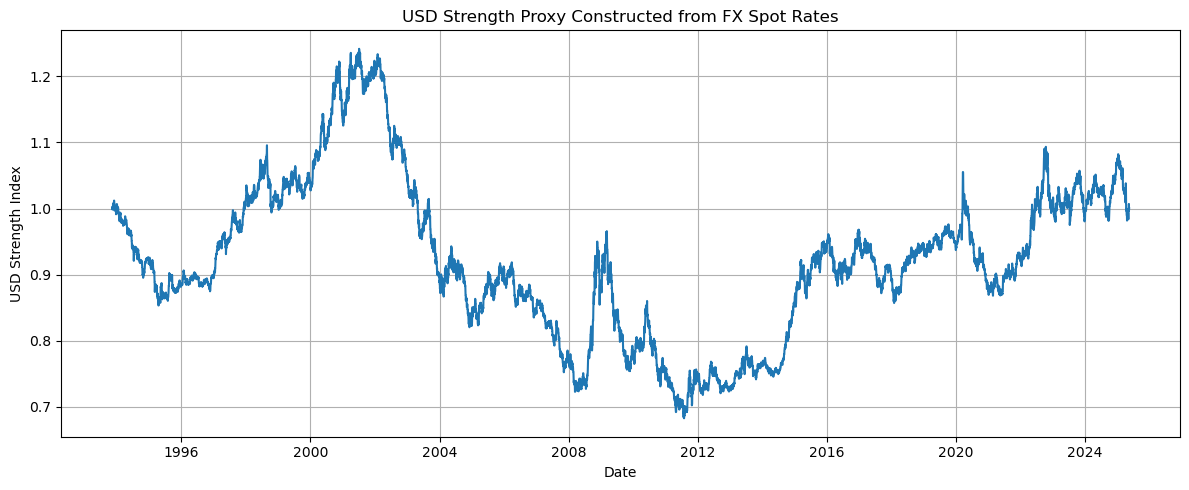

In [82]:
plt.figure(figsize=(12, 5))
plt.plot(usd_strength_index)
plt.title("USD Strength Proxy Constructed from FX Spot Rates")
plt.xlabel("Date")
plt.ylabel("USD Strength Index")
plt.grid(True)
plt.tight_layout()
plt.show()

Proxy VIX

In [83]:
spx_index = equity_indices["SPX INDEX"].dropna()
spx_returns = spx_index.pct_change()
spx_returns.name = "SPX_Return"

spx_returns.head()

Date
1993-11-10         NaN
1993-11-11   -0.002329
1993-11-12    0.005944
1993-11-13    0.000000
1993-11-14    0.000000
Name: SPX_Return, dtype: float64

In [84]:
SPX_VOL_LOOKBACK = 21

spx_realised_vol = (
    spx_returns
    .rolling(window=SPX_VOL_LOOKBACK, min_periods=SPX_VOL_LOOKBACK)
    .std()
    * np.sqrt(252)
)

spx_realised_vol.name = "SPX_Realised_Vol"

spx_realised_vol.head()

Date
1993-11-10   NaN
1993-11-11   NaN
1993-11-12   NaN
1993-11-13   NaN
1993-11-14   NaN
Name: SPX_Realised_Vol, dtype: float64

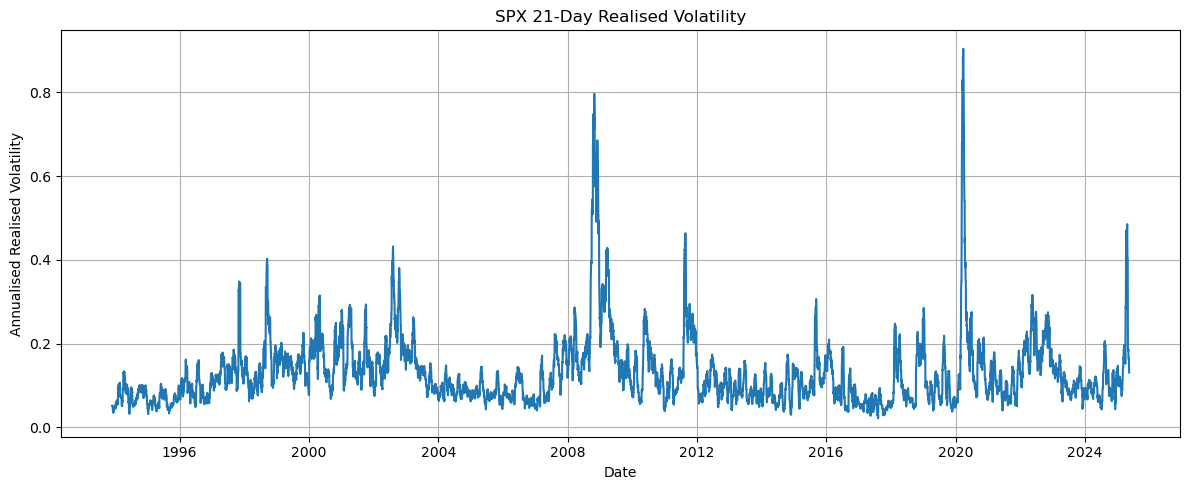

In [85]:
plt.figure(figsize=(12, 5))
plt.plot(spx_realised_vol)
plt.title("SPX 21-Day Realised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised Realised Volatility")
plt.grid(True)
plt.tight_layout()
plt.show()

Combine data sheet

In [86]:
task2_auxiliary = pd.concat(
    [
        usd_strength_return,
        usd_strength_index,
        spx_returns,
        spx_realised_vol
    ],
    axis=1
)

task2_auxiliary = task2_auxiliary.reindex(commodity_returns.index).ffill()

task2_auxiliary.head()

,USD_Strength_Return,USD_Strength_Index,SPX_Return,SPX_Realised_Vol
Date,,,,
1969-01-02,NaN,NaN,NaN,NaN
1969-01-03,NaN,NaN,NaN,NaN
1969-01-06,NaN,NaN,NaN,NaN
1969-01-07,NaN,NaN,NaN,NaN
1969-01-08,NaN,NaN,NaN,NaN


In [87]:
print("Task 2 auxiliary date range:")
print(task2_auxiliary.index.min(), "to", task2_auxiliary.index.max())

print("\nMissing values:")
print(task2_auxiliary.isna().sum())

Task 2 auxiliary date range:
1969-01-02 00:00:00 to 2025-05-15 00:00:00

Missing values:
USD_Strength_Return    6485
USD_Strength_Index     6484
SPX_Return             6485
SPX_Realised_Vol       6499
dtype: int64


Construct SPX Volatility based scaling

In [88]:
spx_vol = task2_auxiliary["SPX_Realised_Vol"].copy()

spx_vol.head()

Date
1969-01-02   NaN
1969-01-03   NaN
1969-01-06   NaN
1969-01-07   NaN
1969-01-08   NaN
Name: SPX_Realised_Vol, dtype: float64

Using train period 80% quantile as the high volatility benchmark

In [102]:
SPX_VOL_TARGET_QUANTILE = 0.80

spx_vol_train = spx_vol.loc[:TRAIN_END].dropna()
spx_vol_target = spx_vol_train.quantile(SPX_VOL_TARGET_QUANTILE)

print("SPX volatility target:", round(spx_vol_target, 4))

SPX volatility target: 0.1682


In [103]:
continuous_spx_vol_scaler = (
    spx_vol_target / spx_vol
).clip(lower=0.5, upper=1.0)

continuous_spx_vol_scaler = continuous_spx_vol_scaler.fillna(1.0)
continuous_spx_vol_scaler.name = "Continuous_SPX_Vol_Scaler"

continuous_spx_vol_scaler.describe().round(4)

count    14706.0000
mean         0.9723
std          0.0936
min          0.5000
25%          1.0000
50%          1.0000
75%          1.0000
max          1.0000
Name: Continuous_SPX_Vol_Scaler, dtype: float64

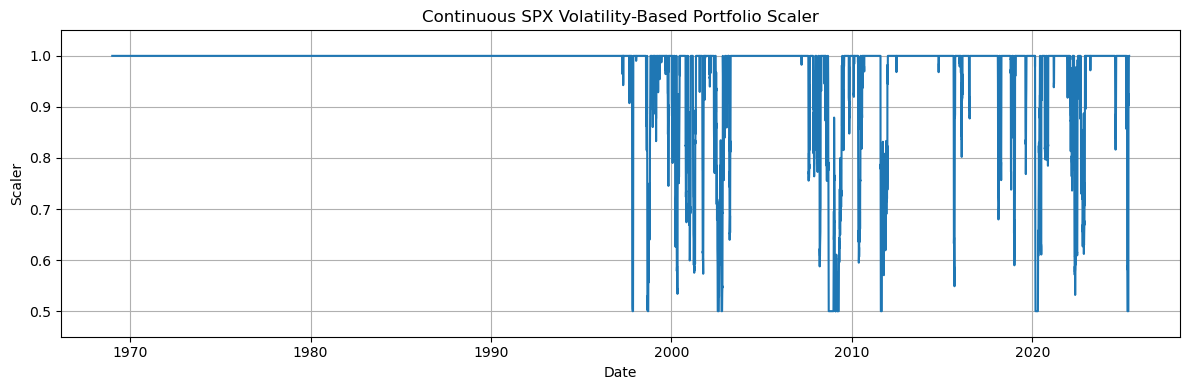

In [104]:
plt.figure(figsize=(12, 4))
plt.plot(continuous_spx_vol_scaler)
plt.title("Continuous SPX Volatility-Based Portfolio Scaler")
plt.xlabel("Date")
plt.ylabel("Scaler")
plt.ylim(0.45, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

In [105]:
continuous_vol_scaled_weights = adaptive_weights.mul(
    continuous_spx_vol_scaler,
    axis=0
)

continuous_vol_scaled_weights.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [106]:
continuous_vol_scaled_gross_exposure = continuous_vol_scaled_weights.abs().sum(axis=1)
continuous_vol_scaled_net_exposure = continuous_vol_scaled_weights.sum(axis=1)

continuous_vol_scaled_exposure_summary = pd.DataFrame({
    "Gross Exposure": continuous_vol_scaled_gross_exposure,
    "Net Exposure": continuous_vol_scaled_net_exposure
})

continuous_vol_scaled_exposure_summary.describe().round(4)

,Gross Exposure,Net Exposure
count,14706.0000,14706.0000
mean,0.9681,0.0190
std,0.1128,0.4501
min,0.0000,-1.0000
25%,1.0000,-0.3167
50%,1.0000,0.0215
75%,1.0000,0.3757
max,1.0000,1.0000


In [107]:
continuous_vol_scaled_strategy_returns, continuous_vol_scaled_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=continuous_vol_scaled_weights,
    strategy_name="Continuous_SPX_Vol_Scaled_Adaptive_TSMOM"
)

continuous_vol_scaled_strategy_returns.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: Continuous_SPX_Vol_Scaled_Adaptive_TSMOM, dtype: float64

In [108]:
vol_scaling_comparison_returns = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM"),
        continuous_vol_scaled_strategy_returns.rename("Continuous_SPX_Vol_Scaled"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

vol_scaling_summary_test = performance_summary(
    vol_scaling_comparison_returns.loc[TEST_START:],
    annualisation=ANNUALISATION
)

vol_scaling_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Continuous_SPX_Vol_Scaled,1402,0.3273,0.0522,0.0546,0.0861,0.6342,0.8689,-0.1761,0.2965,-0.3655,4.2637,0.5121
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


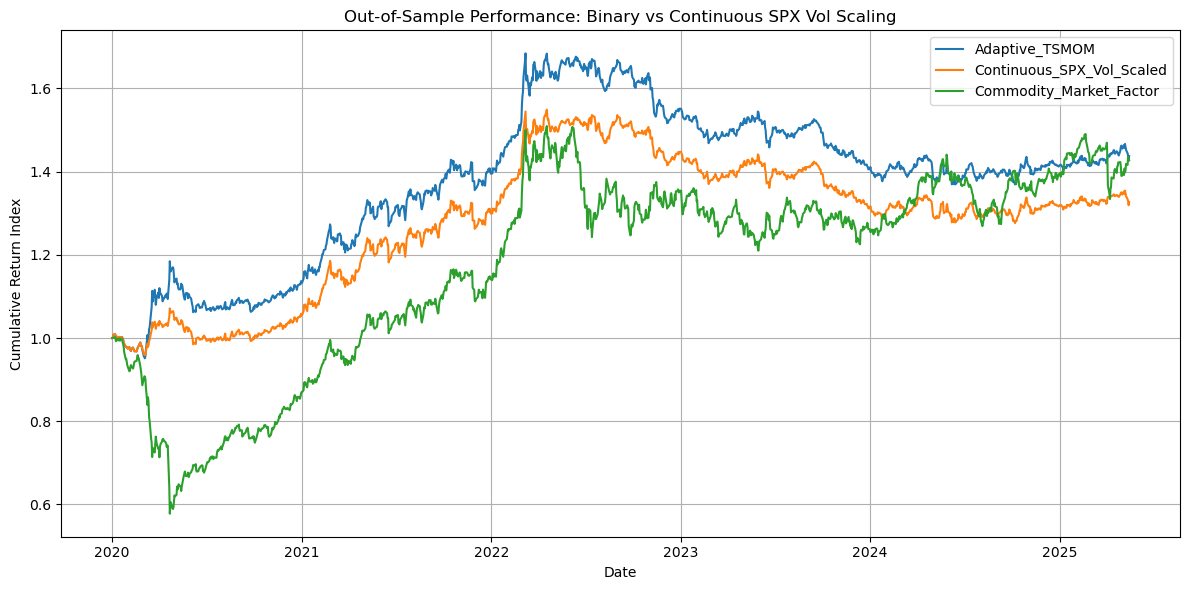

In [109]:
vol_scaling_cum_test = (1 + vol_scaling_comparison_returns.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))

for col in vol_scaling_cum_test.columns:
    plt.plot(vol_scaling_cum_test[col], label=col)

plt.title("Out-of-Sample Performance: Binary vs Continuous SPX Vol Scaling")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We tested an SPX realised-volatility-based notional scaler. It reduced portfolio volatility and slightly improved maximum drawdown, but the reduction in exposure also lowered returns and risk-adjusted performance. Therefore, we do not adopt it as the main enhanced strategy.

USD Strength Metal Overlay

In [110]:
metals_assets = assets.loc[
    assets["Sector"].str.strip().str.lower() == "metals",
    "Commodity"
].tolist()

# 只保留在 adaptive_weights 里面真实存在的商品
metals_assets = [asset for asset in metals_assets if asset in adaptive_weights.columns]

print("Metals assets:")
print(metals_assets)
print("Number of metals assets:", len(metals_assets))

Metals assets:
['COPPER FUTURE', 'GOLD 100 OZ', 'SILVER', 'PLATINUM', 'LME NICKEL', 'LME COPPER', 'LME ALUMINIUM', 'LME LEAD', 'LME ZINC']
Number of metals assets: 9


In [111]:
USD_MOM_LOOKBACK = 63

usd_strength_index_aligned = task2_auxiliary["USD_Strength_Index"].copy()

usd_momentum = usd_strength_index_aligned.pct_change(USD_MOM_LOOKBACK)
usd_momentum.name = "USD_63D_Momentum"

usd_momentum.head()

Date
1969-01-02   NaN
1969-01-03   NaN
1969-01-06   NaN
1969-01-07   NaN
1969-01-08   NaN
Name: USD_63D_Momentum, dtype: float64

In [113]:
usd_strengthening = usd_momentum > 0
usd_strengthening.name = "USD_Strengthening_Regime"

usd_strengthening.value_counts(dropna=False)

USD_Strengthening_Regime
False    10475
True      4231
Name: count, dtype: int64

In [114]:
rebalance_mask = get_rebalance_mask(adaptive_weights.index, REBALANCE_FREQ)

usd_overlay_regime = pd.Series(np.nan, index=adaptive_weights.index, name="USD_Overlay_Regime")

usd_overlay_regime.loc[rebalance_mask] = usd_strengthening.loc[rebalance_mask].astype(float)

usd_overlay_regime = usd_overlay_regime.ffill().fillna(0).astype(bool)

usd_overlay_regime.value_counts(dropna=False)

USD_Overlay_Regime
False    10422
True      4284
Name: count, dtype: int64

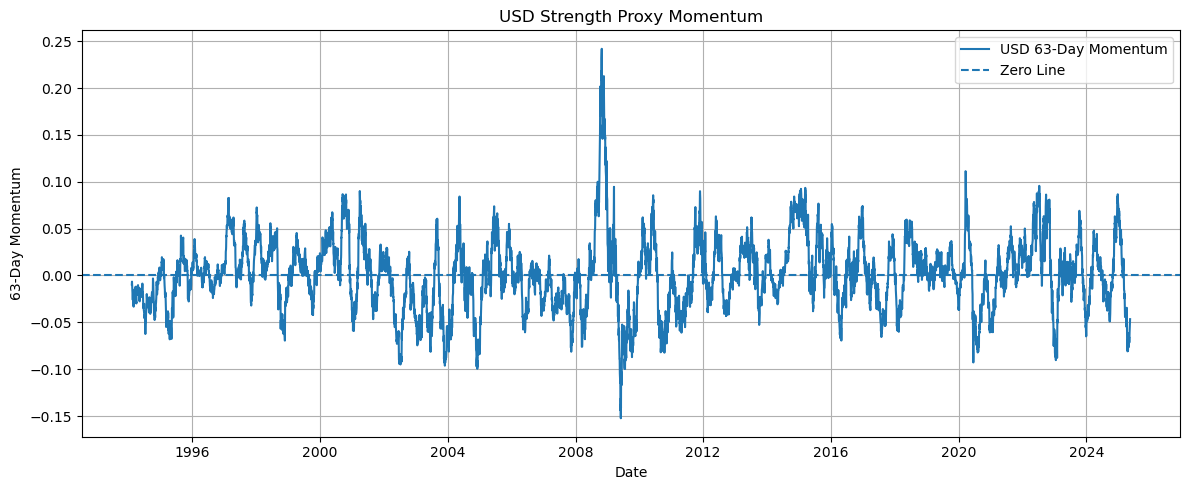

In [115]:
plt.figure(figsize=(12, 5))
plt.plot(usd_momentum, label="USD 63-Day Momentum")
plt.axhline(0, linestyle="--", label="Zero Line")
plt.title("USD Strength Proxy Momentum")
plt.xlabel("Date")
plt.ylabel("63-Day Momentum")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

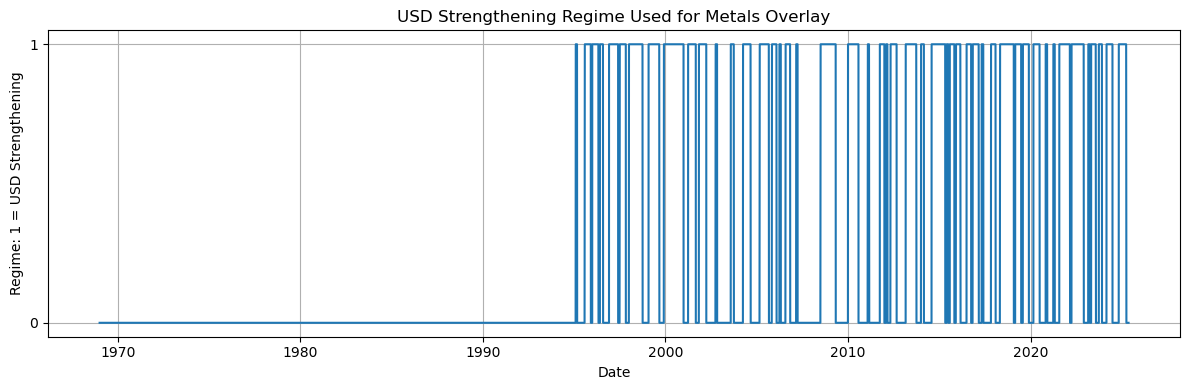

In [116]:
plt.figure(figsize=(12, 4))
plt.plot(usd_overlay_regime.astype(int))
plt.title("USD Strengthening Regime Used for Metals Overlay")
plt.xlabel("Date")
plt.ylabel("Regime: 1 = USD Strengthening")
plt.yticks([0, 1])
plt.grid(True)
plt.tight_layout()
plt.show()

In [117]:
USD_METALS_LONG_SCALER = 0.5

usd_metals_overlay_weights = adaptive_weights.copy()

for asset in metals_assets:
    long_metal_position = usd_metals_overlay_weights[asset] > 0
    adjustment_mask = usd_overlay_regime & long_metal_position
    
    usd_metals_overlay_weights.loc[adjustment_mask, asset] = (
        usd_metals_overlay_weights.loc[adjustment_mask, asset] 
        * USD_METALS_LONG_SCALER
    )

usd_metals_overlay_weights.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1969-01-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
usd_overlay_gross_exposure = usd_metals_overlay_weights.abs().sum(axis=1)
usd_overlay_net_exposure = usd_metals_overlay_weights.sum(axis=1)

usd_overlay_exposure_summary = pd.DataFrame({
    "Gross Exposure": usd_overlay_gross_exposure,
    "Net Exposure": usd_overlay_net_exposure
})

usd_overlay_exposure_summary.describe().round(4)

,Gross Exposure,Net Exposure
count,14706.0000,14706.0000
mean,0.9677,-0.0162
std,0.0865,0.4592
min,0.0000,-1.0000
25%,1.0000,-0.3360
50%,1.0000,-0.0166
75%,1.0000,0.3357
max,1.0000,1.0000


In [119]:
usd_metals_overlay_strategy_returns, usd_metals_overlay_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=usd_metals_overlay_weights,
    strategy_name="USD_Metals_Overlay_Adaptive_TSMOM"
)

usd_metals_overlay_strategy_returns.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: USD_Metals_Overlay_Adaptive_TSMOM, dtype: float64

In [120]:
usd_overlay_comparison_returns = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM"),
        usd_metals_overlay_strategy_returns.rename("USD_Metals_Overlay"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

usd_overlay_summary_test = performance_summary(
    usd_overlay_comparison_returns.loc[TEST_START:],
    annualisation=ANNUALISATION
)

usd_overlay_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
USD_Metals_Overlay,1402,0.3892,0.0609,0.0636,0.0955,0.6666,0.9520,-0.1867,0.3260,0.4729,8.5753,0.5128
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


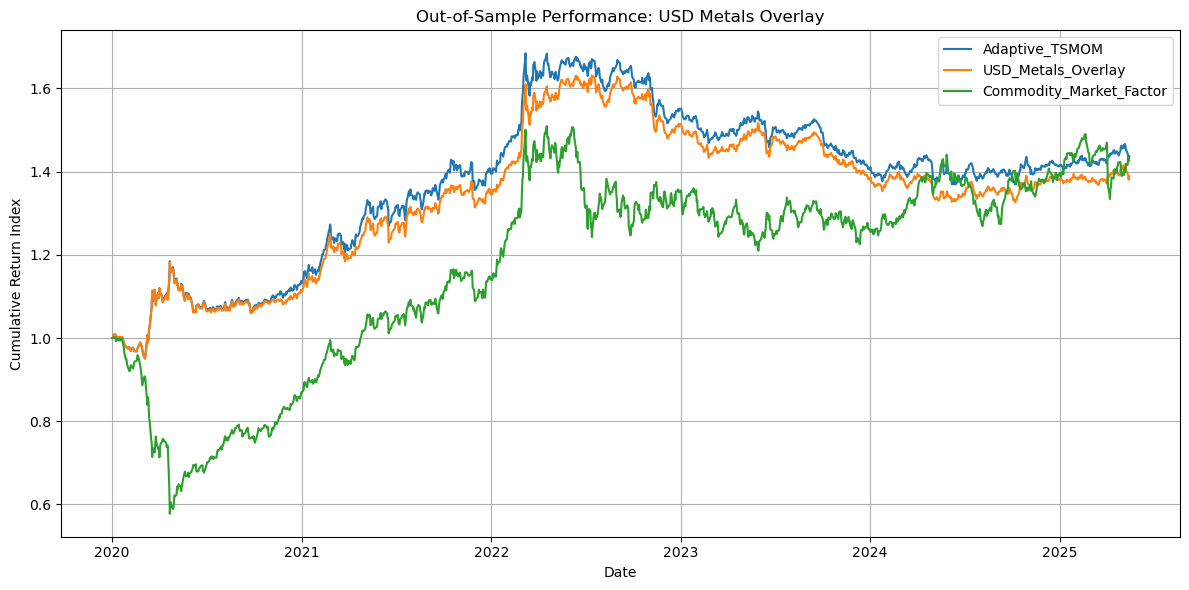

In [121]:
usd_overlay_cum_test = (1 + usd_overlay_comparison_returns.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))

for col in usd_overlay_cum_test.columns:
    plt.plot(usd_overlay_cum_test[col], label=col)

plt.title("Out-of-Sample Performance: USD Metals Overlay")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We test a USD-strength-based metals overlay motivated by the fact that metals are USD-denominated and may face headwinds when the dollar strengthens. However, the overlay reduces cumulative returns and risk-adjusted performance, while only marginally reducing volatility and drawdown. We therefore do not adopt this overlay as the final enhancement. This suggests that the baseline Adaptive TSMOM signal already captures metals trends more effectively than the additional USD filter.

Transaction cost analysis

In [122]:
adaptive_turnover = adaptive_weights.diff().abs().sum(axis=1)
adaptive_turnover.name = "Adaptive_TSMOM_Turnover"

adaptive_turnover.describe().round(4)

count    14706.0000
mean         0.0180
std          0.0945
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          1.3310
Name: Adaptive_TSMOM_Turnover, dtype: float64

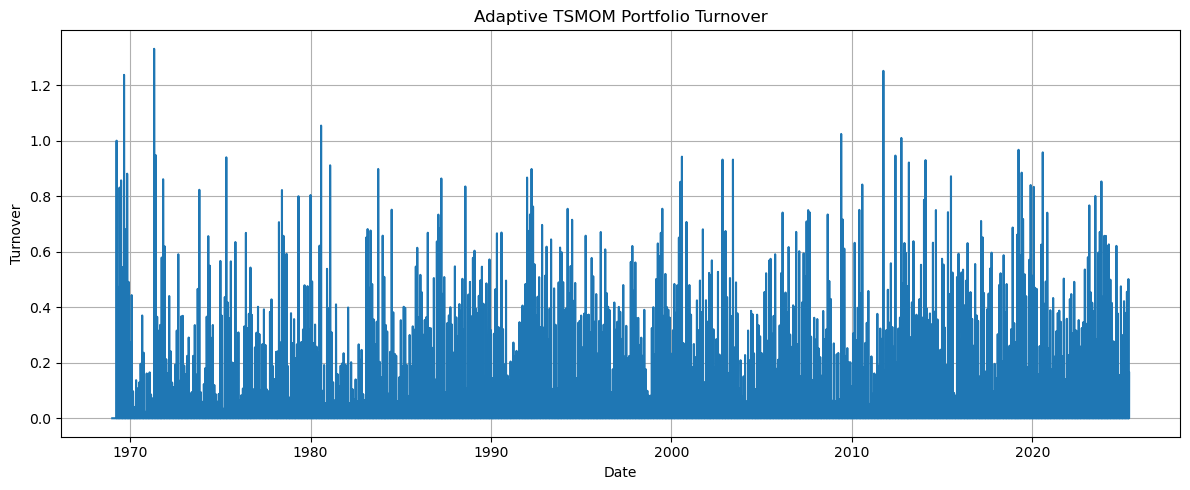

In [123]:
plt.figure(figsize=(12, 5))
plt.plot(adaptive_turnover)
plt.title("Adaptive TSMOM Portfolio Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
TRANSACTION_COST_RATE = 0.0025   # 0.25%

In [125]:
adaptive_transaction_cost = TRANSACTION_COST_RATE * adaptive_turnover
adaptive_transaction_cost.name = "Adaptive_TSMOM_Transaction_Cost"

adaptive_transaction_cost.describe().round(6)

count    14706.000000
mean         0.000045
std          0.000236
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.003327
Name: Adaptive_TSMOM_Transaction_Cost, dtype: float64

In [126]:
adaptive_strategy_returns_net = (
    adaptive_strategy_returns 
    - adaptive_transaction_cost.reindex(adaptive_strategy_returns.index).fillna(0)
)

adaptive_strategy_returns_net.name = "Adaptive_TSMOM_Net_of_TC"

adaptive_strategy_returns_net.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: Adaptive_TSMOM_Net_of_TC, dtype: float64

In [127]:
tc_comparison_returns = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM_Gross"),
        adaptive_strategy_returns_net.rename("Adaptive_TSMOM_Net_of_TC"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

tc_summary_test = performance_summary(
    tc_comparison_returns.loc[TEST_START:],
    annualisation=ANNUALISATION
)

tc_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM_Gross,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Adaptive_TSMOM_Net_of_TC,1402,0.3386,0.0538,0.0573,0.0993,0.5774,0.8241,-0.2168,0.2482,0.3621,7.2054,0.5064
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


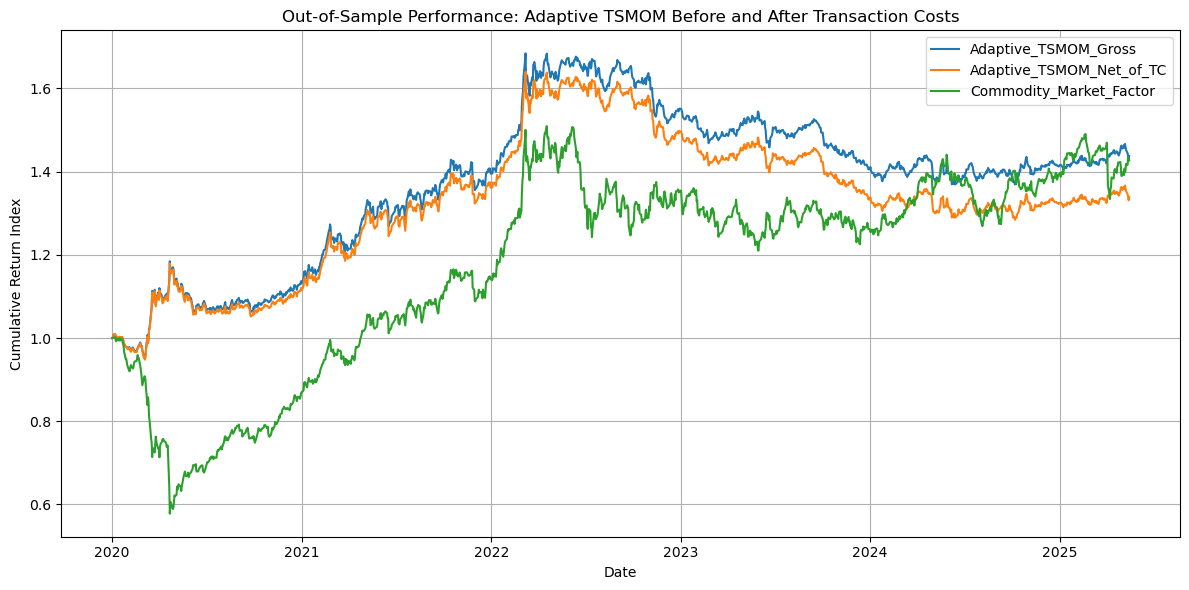

In [128]:
tc_cum_test = (1 + tc_comparison_returns.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))

for col in tc_cum_test.columns:
    plt.plot(tc_cum_test[col], label=col)

plt.title("Out-of-Sample Performance: Adaptive TSMOM Before and After Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [129]:
tc_rates = {
    "0bps": 0.0000,
    "10bps": 0.0010,
    "25bps": 0.0025,
    "50bps": 0.0050
}

tc_sensitivity_returns = {}

for label, cost_rate in tc_rates.items():
    tc = cost_rate * adaptive_turnover
    net_ret = adaptive_strategy_returns - tc.reindex(adaptive_strategy_returns.index).fillna(0)
    net_ret.name = f"Net_TC_{label}"
    tc_sensitivity_returns[label] = net_ret

tc_sensitivity_df = pd.concat(tc_sensitivity_returns.values(), axis=1).dropna()

tc_sensitivity_summary_test = performance_summary(
    tc_sensitivity_df.loc[TEST_START:],
    annualisation=ANNUALISATION
)

tc_sensitivity_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Net_TC_0bps,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Net_TC_10bps,1402,0.3970,0.0619,0.0650,0.0991,0.6561,0.9360,-0.1991,0.3110,0.3660,7.2741,0.5086
Net_TC_25bps,1402,0.3386,0.0538,0.0573,0.0993,0.5774,0.8241,-0.2168,0.2482,0.3621,7.2054,0.5064
Net_TC_50bps,1402,0.2467,0.0404,0.0446,0.0999,0.4466,0.6364,-0.2455,0.1647,0.3496,7.0579,0.5036


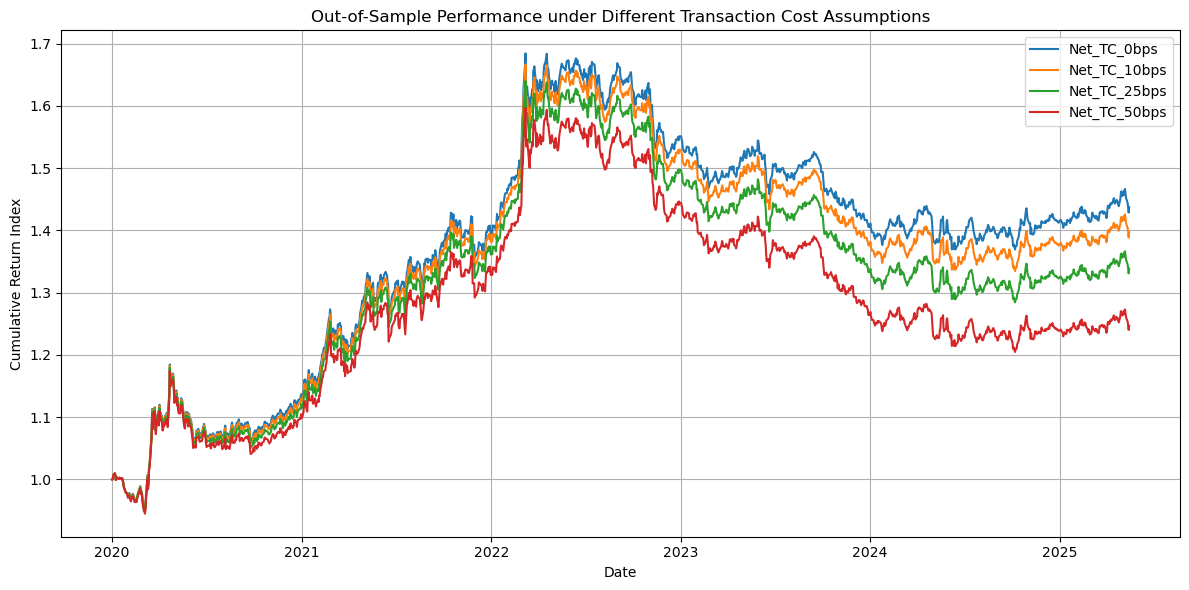

In [130]:
tc_sensitivity_cum_test = (1 + tc_sensitivity_df.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))

for col in tc_sensitivity_cum_test.columns:
    plt.plot(tc_sensitivity_cum_test[col], label=col)

plt.title("Out-of-Sample Performance under Different Transaction Cost Assumptions")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Turnover control

In [131]:
def apply_no_trade_band(target_weights, returns=None, band=0.01):

    target_weights = target_weights.copy()
    target_weights = target_weights.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    implemented_weights = pd.DataFrame(
        0.0,
        index=target_weights.index,
        columns=target_weights.columns
    )

    realised_turnover = pd.Series(
        0.0,
        index=target_weights.index,
        name="No_Trade_Band_Turnover"
    )

    previous_weights = pd.Series(
        0.0,
        index=target_weights.columns
    )

    for date in target_weights.index:
        current_target = target_weights.loc[date].copy()

        # If returns are unavailable for an asset, force its target and previous weight to zero
        if returns is not None and date in returns.index:
            valid_assets = returns.loc[date].notna()
            current_target = current_target.where(valid_assets, 0.0)
            previous_weights = previous_weights.where(valid_assets, 0.0)

        weight_change = current_target - previous_weights

        # Only trade positions where the required change exceeds the band
        trade_mask = weight_change.abs() >= band

        new_weights = previous_weights.copy()
        new_weights.loc[trade_mask] = current_target.loc[trade_mask]

        implemented_weights.loc[date] = new_weights

        realised_turnover.loc[date] = (new_weights - previous_weights).abs().sum()

        previous_weights = new_weights.copy()

    return implemented_weights, realised_turnover

In [140]:
NO_TRADE_BAND = 0.01  # 1% absolute weight threshold

no_trade_weights, no_trade_turnover = apply_no_trade_band(
    target_weights=adaptive_weights,
    returns=commodity_returns,
    band=NO_TRADE_BAND
)

In [133]:
original_turnover = adaptive_weights.diff().abs().sum(axis=1)
original_turnover.name = "Original_Turnover"

turnover_comparison = pd.concat(
    [
        original_turnover,
        no_trade_turnover
    ],
    axis=1
)

turnover_comparison_test = turnover_comparison.loc[TEST_START:]

turnover_summary = pd.DataFrame({
    "Average Daily Turnover": turnover_comparison_test.mean(),
    "Median Daily Turnover": turnover_comparison_test.median(),
    "Annualised Turnover": turnover_comparison_test.mean() * 252,
    "Total Turnover": turnover_comparison_test.sum()
})

turnover_summary.round(4)

,Average Daily Turnover,Median Daily Turnover,Annualised Turnover,Total Turnover
Original_Turnover,0.0202,0.0,5.0963,28.3531
No_Trade_Band_Turnover,0.0185,0.0,4.6518,25.8804


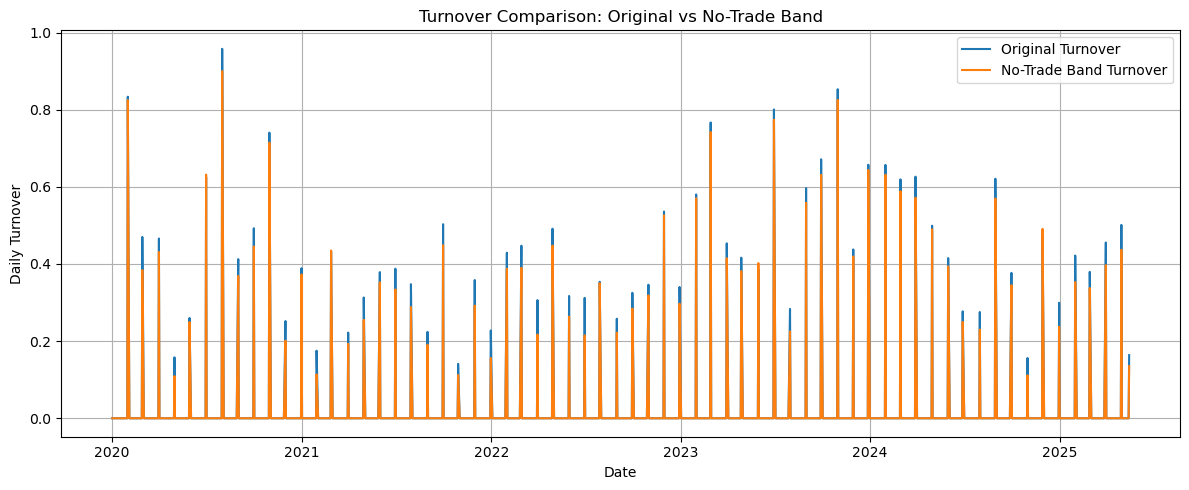

In [134]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_comparison_test["Original_Turnover"], label="Original Turnover")
plt.plot(turnover_comparison_test["No_Trade_Band_Turnover"], label="No-Trade Band Turnover")
plt.title("Turnover Comparison: Original vs No-Trade Band")
plt.xlabel("Date")
plt.ylabel("Daily Turnover")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [135]:
no_trade_strategy_returns_gross, no_trade_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=no_trade_weights,
    strategy_name="No_Trade_Band_Adaptive_TSMOM_Gross"
)

no_trade_strategy_returns_gross.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: No_Trade_Band_Adaptive_TSMOM_Gross, dtype: float64

In [136]:
TRANSACTION_COST_RATE = 0.0025  # 25bps

no_trade_transaction_cost = TRANSACTION_COST_RATE * no_trade_turnover

no_trade_strategy_returns_net = (
    no_trade_strategy_returns_gross
    - no_trade_transaction_cost.reindex(no_trade_strategy_returns_gross.index).fillna(0.0)
)

no_trade_strategy_returns_net.name = "No_Trade_Band_Adaptive_TSMOM_Net"

In [137]:
adaptive_transaction_cost = TRANSACTION_COST_RATE * original_turnover

adaptive_strategy_returns_net = (
    adaptive_strategy_returns
    - adaptive_transaction_cost.reindex(adaptive_strategy_returns.index).fillna(0.0)
)

adaptive_strategy_returns_net.name = "Adaptive_TSMOM_Net"

In [138]:
no_trade_comparison_returns = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM_Gross"),
        adaptive_strategy_returns_net.rename("Adaptive_TSMOM_Net"),
        no_trade_strategy_returns_gross.rename("No_Trade_Band_Gross"),
        no_trade_strategy_returns_net.rename("No_Trade_Band_Net"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

no_trade_summary_test = performance_summary(
    no_trade_comparison_returns.loc[TEST_START:],
    annualisation=ANNUALISATION
)

no_trade_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM_Gross,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Adaptive_TSMOM_Net,1402,0.3386,0.0538,0.0573,0.0993,0.5774,0.8241,-0.2168,0.2482,0.3621,7.2054,0.5064
No_Trade_Band_Gross,1402,0.4458,0.0685,0.0712,0.0996,0.7151,1.0297,-0.1832,0.3741,0.3935,7.1569,0.5107
No_Trade_Band_Net,1402,0.3550,0.0561,0.0596,0.1000,0.5962,0.8593,-0.2105,0.2666,0.3890,7.0650,0.5050
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


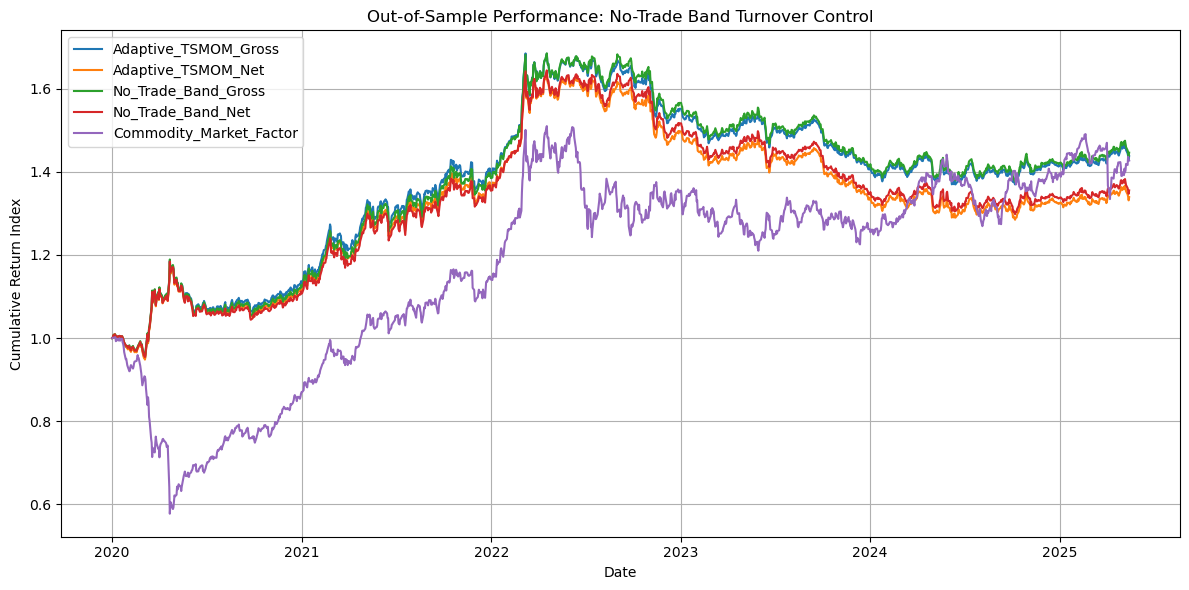

In [139]:
no_trade_cum_test = (1 + no_trade_comparison_returns.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))

for col in no_trade_cum_test.columns:
    plt.plot(no_trade_cum_test[col], label=col)

plt.title("Out-of-Sample Performance: No-Trade Band Turnover Control")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The no-trade band is introduced to reduce unnecessary rebalancing when target weight changes are small. Under a 1% absolute-weight threshold, annualised turnover falls from 5.10 to 4.65. More importantly, the net-of-cost out-of-sample Sharpe ratio improves from 0.577 to 0.596 under a 25bps transaction cost assumption. The improvement is modest but consistent across CAGR, Sortino ratio, maximum drawdown and Calmar ratio. This suggests that some small rebalancing trades in the baseline Adaptive TSMOM strategy do not contribute enough to offset implementation costs.

Using train sample to select the most effetive threshold from  [0.000, 0.005, 0.010, 0.020]

In [141]:
candidate_bands = [0.000, 0.005, 0.010, 0.020]

TRANSACTION_COST_RATE = 0.0025

In [142]:
band_selection_results = []

for band in candidate_bands:
    # Apply no-trade band
    band_weights, band_turnover = apply_no_trade_band(
        target_weights=adaptive_weights,
        returns=commodity_returns,
        band=band
    )
    
    # Backtest gross returns
    band_gross_returns, _ = backtest_from_weights(
        returns=commodity_returns,
        weights=band_weights,
        strategy_name=f"No_Trade_Band_{band:.3f}_Gross"
    )
    
    # Transaction cost
    band_transaction_cost = TRANSACTION_COST_RATE * band_turnover
    
    # Net returns
    band_net_returns = (
        band_gross_returns
        - band_transaction_cost.reindex(band_gross_returns.index).fillna(0.0)
    )
    
    band_net_returns.name = f"No_Trade_Band_{band:.3f}_Net"
    
    # Training sample only
    train_net_returns = band_net_returns.loc[:TRAIN_END]
    train_turnover = band_turnover.loc[:TRAIN_END]
    
    # Performance summary
    train_summary = performance_summary(
        train_net_returns,
        annualisation=ANNUALISATION
    )
    
    row = train_summary.loc[band_net_returns.name].copy()
    row["Band"] = band
    row["Average Daily Turnover"] = train_turnover.mean()
    row["Annualised Turnover"] = train_turnover.mean() * 252
    row["Total Turnover"] = train_turnover.sum()
    
    band_selection_results.append(row)

band_selection_table_train = pd.DataFrame(band_selection_results)
band_selection_table_train = band_selection_table_train.set_index("Band")

band_selection_table_train.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate,Average Daily Turnover,Annualised Turnover,Total Turnover
Band,,,,,,,,,,,,,,,
0.000,13241.0,29.0374,0.0669,0.0687,0.0885,0.7759,1.0690,-0.3737,0.1790,-0.1666,5.4240,0.5164,0.0178,4.4859,236.8288
0.005,13241.0,29.5812,0.0673,0.0690,0.0886,0.7794,1.0735,-0.3681,0.1827,-0.1694,5.4169,0.5155,0.0171,4.3172,227.9208
0.010,13241.0,31.2654,0.0684,0.0701,0.0894,0.7840,1.0783,-0.3766,0.1815,-0.1638,5.7286,0.5160,0.0164,4.1448,218.8166
0.020,13241.0,29.9465,0.0675,0.0694,0.0902,0.7692,1.0599,-0.3644,0.1852,-0.1726,5.1570,0.5185,0.0155,3.9141,206.6375


In [143]:
selected_band = band_selection_table_train["Sharpe Ratio"].idxmax()

print("Selected no-trade band based on training-sample net Sharpe:", selected_band)

Selected no-trade band based on training-sample net Sharpe: 0.01


In [144]:
selected_band = 0.01

final_no_trade_weights = no_trade_weights.copy()
final_no_trade_turnover = no_trade_turnover.copy()
final_no_trade_gross_returns = no_trade_strategy_returns_gross.copy()
final_no_trade_net_returns = no_trade_strategy_returns_net.copy()

final_no_trade_gross_returns.name = "Final_No_Trade_Band_Gross"
final_no_trade_net_returns.name = "Final_No_Trade_Band_Net"

In [145]:
final_no_trade_summary_test = no_trade_summary_test.copy()

final_no_trade_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM_Gross,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Adaptive_TSMOM_Net,1402,0.3386,0.0538,0.0573,0.0993,0.5774,0.8241,-0.2168,0.2482,0.3621,7.2054,0.5064
No_Trade_Band_Gross,1402,0.4458,0.0685,0.0712,0.0996,0.7151,1.0297,-0.1832,0.3741,0.3935,7.1569,0.5107
No_Trade_Band_Net,1402,0.3550,0.0561,0.0596,0.1000,0.5962,0.8593,-0.2105,0.2666,0.3890,7.0650,0.5050
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


The no-trade band threshold is selected using the training sample only. We compare a small set of economically interpretable thresholds: 0%, 0.5%, 1.0%, and 2.0%. The 1.0% band provides the best balance between net-of-cost Sharpe ratio, turnover reduction, and drawdown control in the training sample. We therefore fix the 1.0% threshold before evaluating the strategy in the post-2020 test sample.